# GNN
## Sheet 1
- Thorsten Trinkaus
- Suryansh Chaturvedi

---
## Task 1
---

<div style="color: green; font-weight: bold">

### OVERALL COMMENTS:
The samples generated by the models and the true data are nicely presented side-to-side.

They included guards against tiny negative values (MMD^2) or log(0) (2d-Hist.), which renders the code more robust. 


- MORE COMMENtS?
</div>

---
### Imports
---

In [1]:
import numpy as np
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.metrics.pairwise import euclidean_distances

---
### 2D Histogram
---
This Model either takes a fixed bin size or utilizes the Freedman–Diaconis rule to determine bin size.

<div style="color: green; font-weight: bold">
They use individual vectors for each dimension instead of tuple/matrix approach from the given solution. This creates some redundancy in the code but does not change its functionality.

FIT():

- The bin_size can be provided or is calculated via IQR (Freedman-Diaconis Rule) as an additional function compared to solution.

- The bin weights are calculated with a for loop. Here, using np.digitize would have been more efficient.

- There is an option to fit the model simultaneously if a training set is provided during initialization.

SAMPLE():

- First part of the function uses same logic as solution, then a for loop is used, which would be slow for large data sets. Reconstructing the 2D coordinates as in the given solution would have been more elegant.

SCORE_SAMPLES():
- score_samples() function returns log densities, as in the sklearn API. Even though the predict() function returns densities, score_samples() is still a valid way to compare model quality (via MMD^2), since they implemented this logic throughout all models.

- Again, calculations are not vectorized, which is inefficient for large data sets.

- Including small constant eps to avoid log(0) renders the code more robust, but also gives it a slight downwards bias.

- Checking the range is included -> same functionality as in solution.
</div>

#### Class

In [2]:
class Histogram2DModel:
    
    def __init__(self, h=None, X=None):
        """
        Initializes the Model.

        Parameters
        ----------
        h : float, optional
            Bin width for both dimensions. 
            If None, the Freedman–Diaconis rule is used.
        X : array-like, shape (n_samples, 2), optional
            Input data to fit the model. 
            If provided, the model is fitted during initialization.
        """

        # Number of bins along each axis.
        self.bins_x = None
        self.bins_y = None

        # Minimum values along each axis.
        self.min_x = None
        self.min_y = None

        # Bin sizes for each bin.
        self.h_x = h
        self.h_y = h

        # Weights for each bin.
        self.bin_weights = None

        if X is not None:
            self.fit(X)
    
    def fit(self, X):
        """
        Fits the histogram model to data using
        the Freedman–Diaconis rule to determine bin width
        in both dimensions if h is None.

        Parameters
        ----------
        X : array-like, shape (n_samples, 2)
            Input data to fit the model.
        """
        
        # Much of this method could be replaced by np.histogram2d,
        # but that felt like cheating.

        # Calculate bin sizes.
        eps = 1e-8  # small constant.

        if self.h_x is None:
            q75_x, q25_x = np.percentile(X[:, 0], [75 ,25])
            iqr_x = q75_x - q25_x
            self.h_x = 2 * iqr_x * (len(X) ** (-1/3))
        self.bins_x = int(np.ceil((X[:, 0].max() - X[:, 0].min() + eps) / self.h_x))

        if self.h_y is None:
            q75_y, q25_y = np.percentile(X[:, 1], [75 ,25])
            iqr_y = q75_y - q25_y
            self.h_y = 2 * iqr_y * (len(X) ** (-1/3))
        self.bins_y = int(np.ceil((X[:, 1].max() - X[:, 1].min() + eps) / self.h_y))

        # Compute weights for each bin.
        self.bin_weights = np.zeros((self.bins_x, self.bins_y))

        self.min_x = X[:, 0].min() - eps
        self.min_y = X[:, 1].min() - eps

        for s in X:
            bin_x = int(np.floor((s[0] - self.min_x) / self.h_x))
            bin_y = int(np.floor((s[1] - self.min_y) / self.h_y))
            self.bin_weights[bin_x, bin_y] += 1

        # Normalize weights to sum to 1.
        self.bin_weights /= len(X)

        return self

    def sample(self, n_samples):
        """
        Generates samples.

        Parameters
        ----------
        n_samples : int
            Number of samples.

        Returns
        -------
        samples : array-like, shape (n_samples, 2)
        """

        if self.bin_weights is None:
            raise ValueError("Model must be fitted before sampling.")

        samples = np.zeros((n_samples, 2))

        # Flatten bin weights for sampling.
        flat_weights = self.bin_weights.flatten()
        bin_idx = np.arange(len(flat_weights))

        # Sample bins according to their weights.
        choices = np.random.choice(bin_idx, size=n_samples, p=flat_weights)

        # Sample within bins.
        for i, bin_index in enumerate(choices):
            bin_x = bin_index // self.bins_y
            bin_y = bin_index % self.bins_y

            # Sample uniformly within the chosen bin.
            sample_x = self.min_x + bin_x * self.h_x + np.random.uniform(0, self.h_x)
            sample_y = self.min_y + bin_y * self.h_y + np.random.uniform(0, self.h_y)

            samples[i] = [sample_x, sample_y]

        return samples
    
    def score_samples(self, X):
        """
        Compute the log-likelihood of each sample.

        Parameters
        ----------
        X : array-like, shape (n_samples, 2)
            Input data.

        Returns
        -------
        log_likelihoods : array-like, shape (n_samples,)
            Log-likelihood of each sample.
        """

        if self.bin_weights is None:
            raise ValueError("Model must be fitted before scoring.")

        log_likelihoods = np.zeros(len(X))

        eps = 1e-8  # small constant to avoid log(0).

        for i, s in enumerate(X):
            bin_x = int(np.floor((s[0] - self.min_x) / self.h_x))
            bin_y = int(np.floor((s[1] - self.min_y) / self.h_y))

            # Check if the sample falls outside the histogram range.
            if bin_x < 0 or bin_x >= self.bins_x or bin_y < 0 or bin_y >= self.bins_y:
                log_likelihoods[i] = -np.inf
            else:
                # p_k = N_k / (N * h_x * h_y)
                prob = self.bin_weights[bin_x, bin_y] / (self.h_x * self.h_y)
                log_likelihoods[i] = np.log(prob + eps)

        return log_likelihoods


#### Test 1 | Freedman-Diaconis

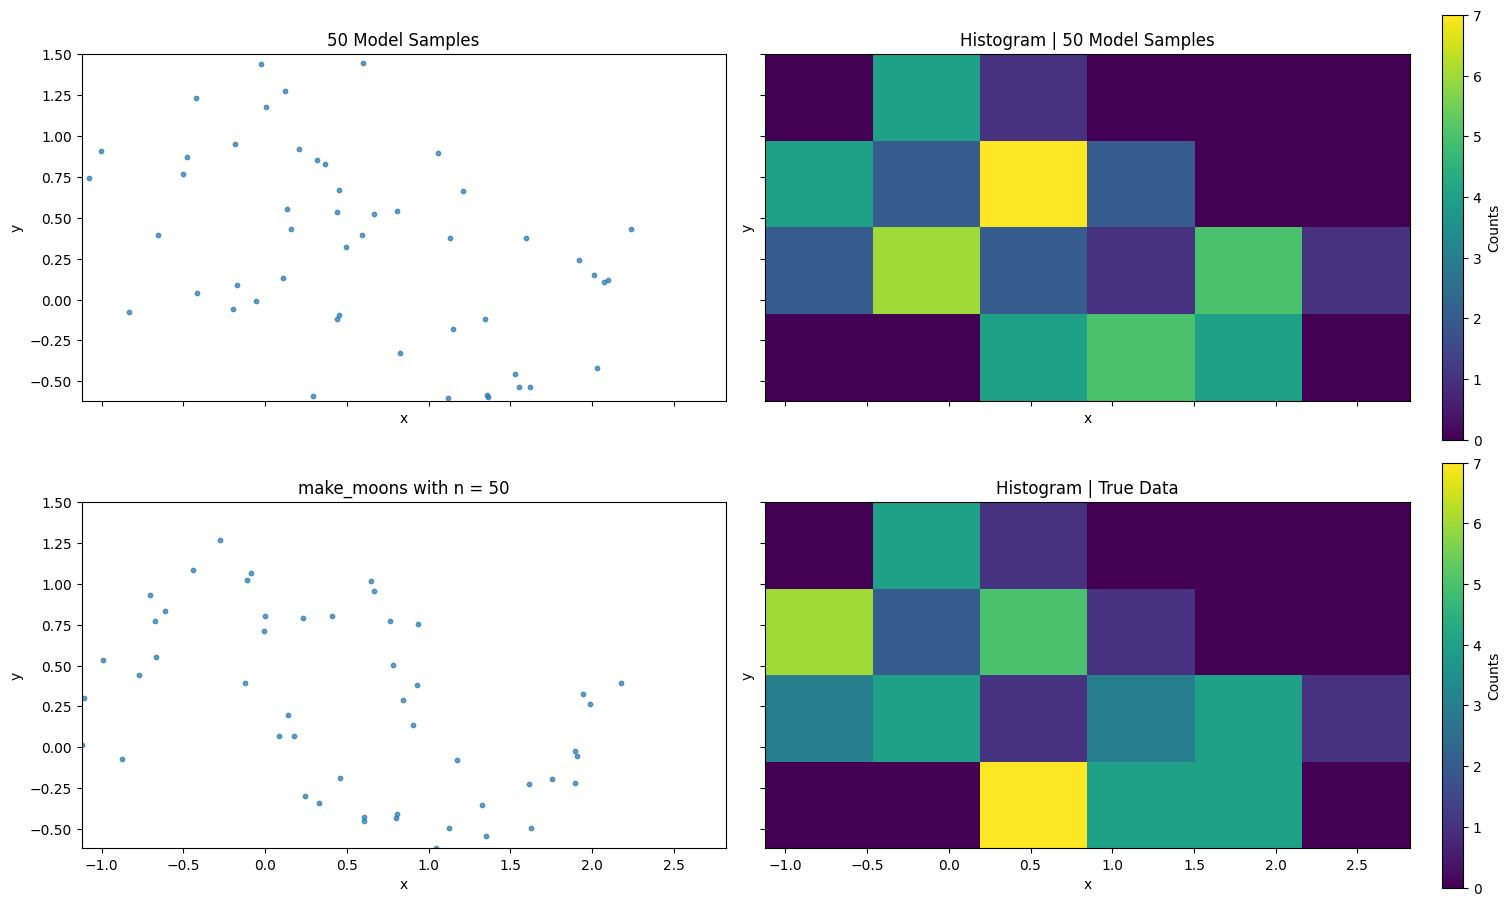

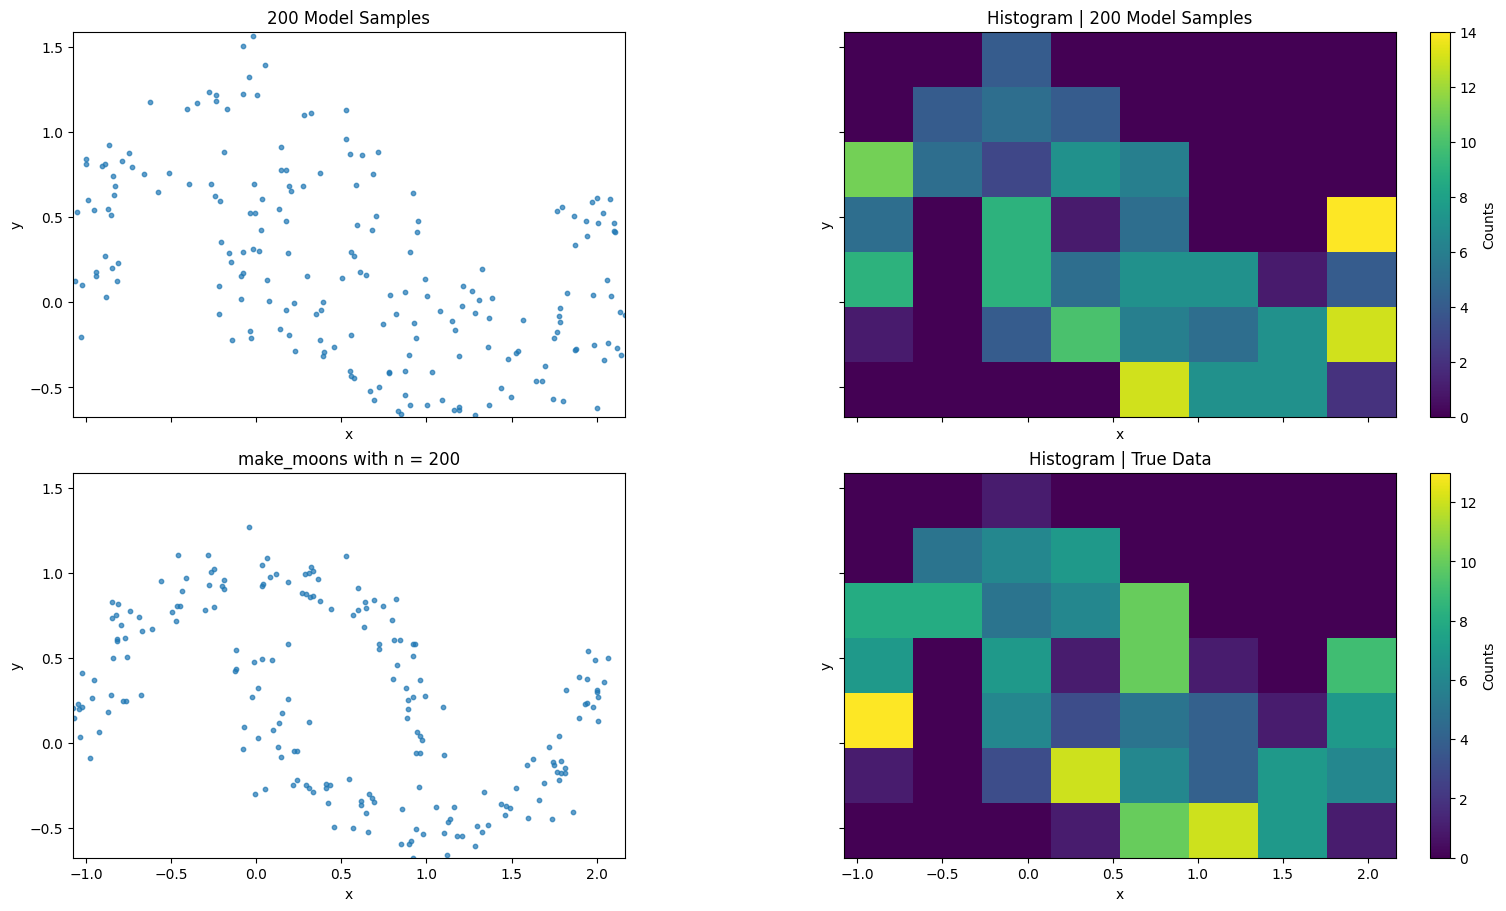

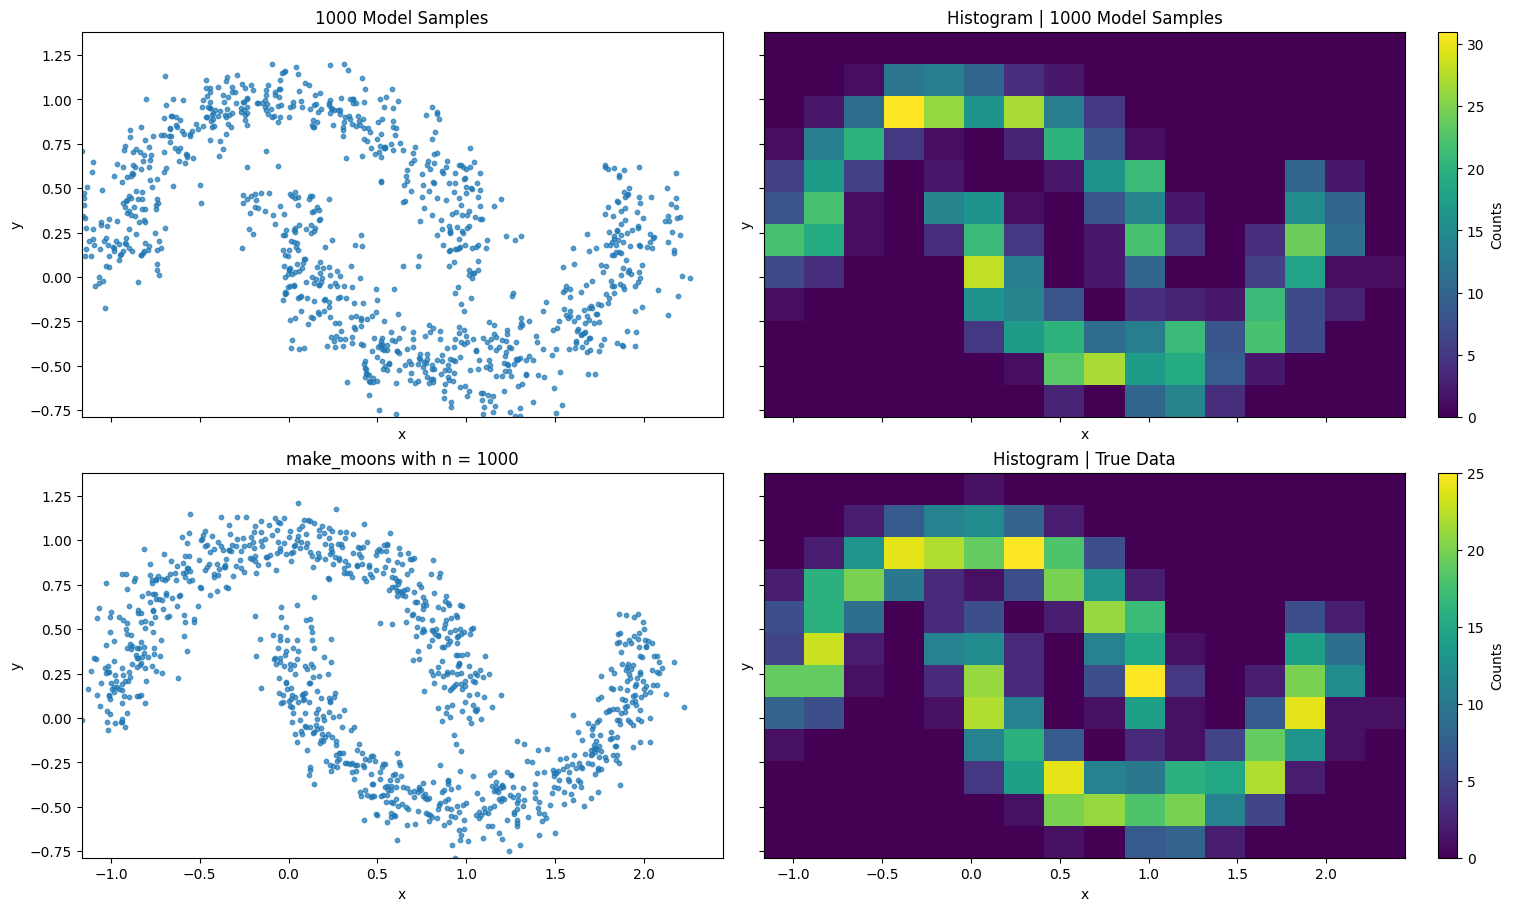

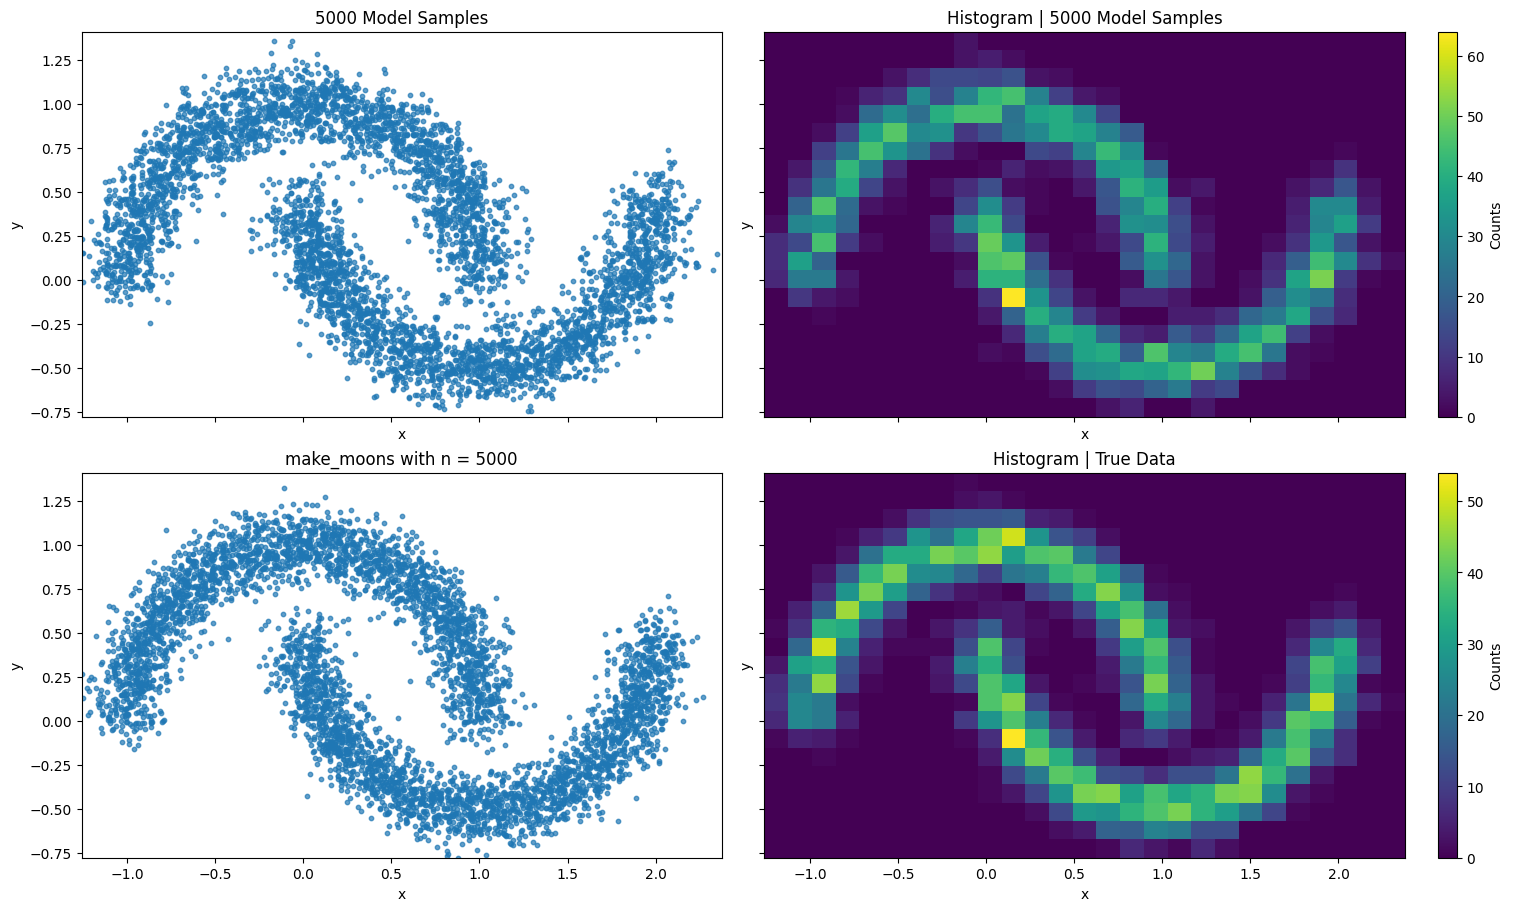

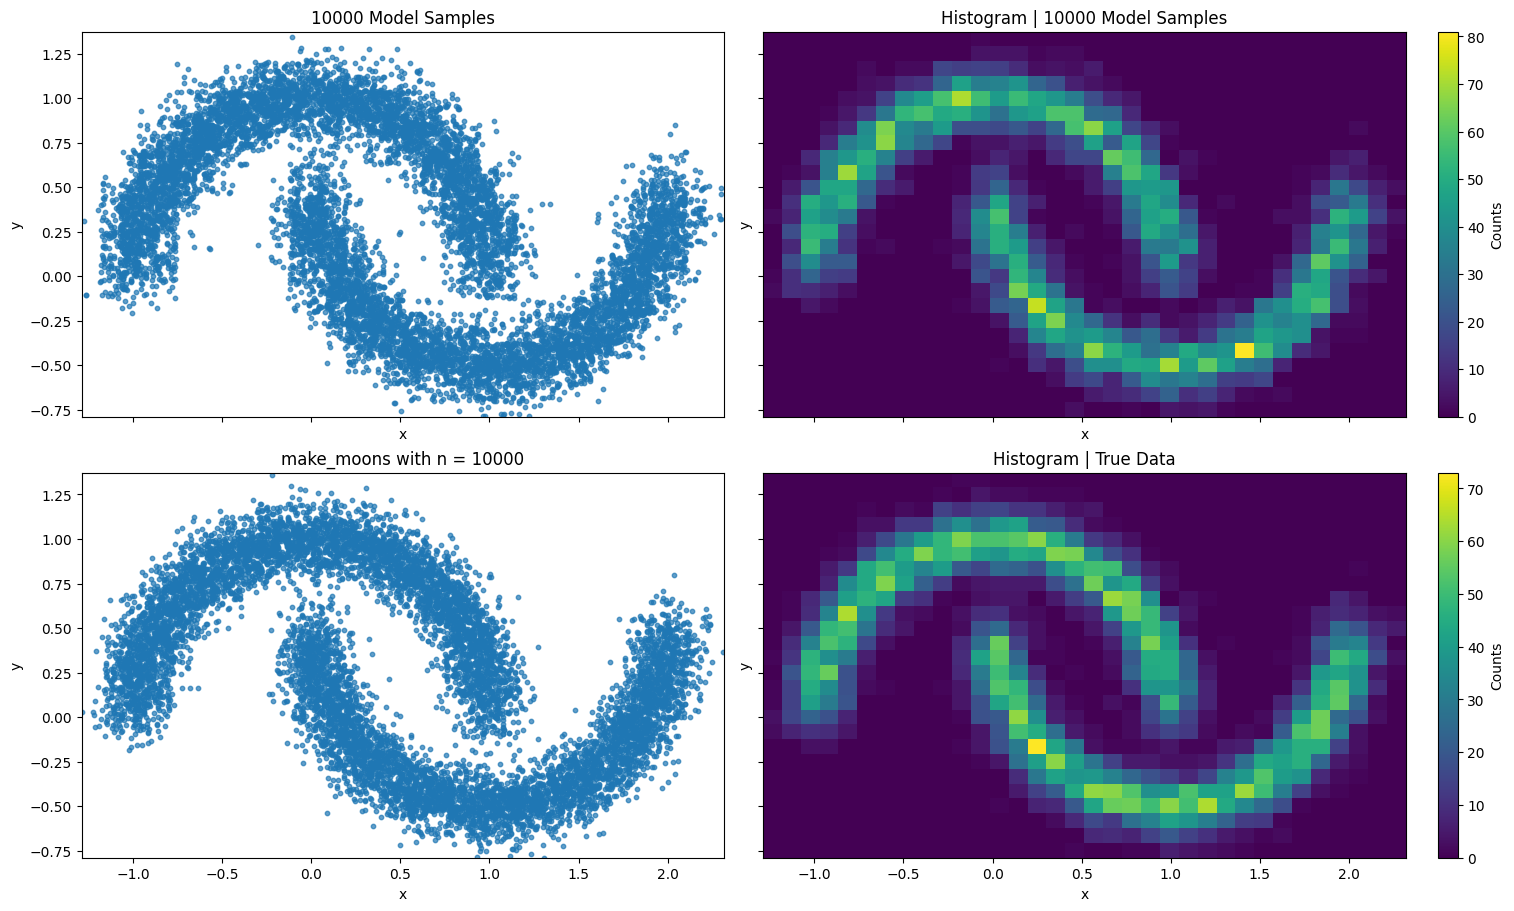

In [3]:
# Create moons datasets and try to fit models.
for n in [50, 200, 1000, 5000, 10000]:
    # Dataset.
    X, _ = make_moons(n_samples=n, noise=0.1)

    # Fit histogram model.
    model = Histogram2DModel(X=X)

    # Sample from the model.
    samples = model.sample(n)

    # Compute bin sizes for plotting.
    min_x = model.min_x
    min_y = model.min_y
    max_x = model.min_x + model.bins_x * model.h_x
    max_y = model.min_y + model.bins_y * model.h_y

    # Plot with sampled data, true data, 
    # and histograms of samples and true data.
    fig, axes = plt.subplots(
        2, 2, 
        figsize=(15, 9), 
        constrained_layout=True, 
        sharex=True, 
        sharey=True
    )
    
    # The model samples.
    axes[0,0].scatter(samples[:, 0], samples[:, 1], s=10, alpha=0.7)
    axes[0,0].set_title(f"{n} Model Samples")
    axes[0,0].set_xlabel("x")
    axes[0,0].set_ylabel("y")

    # The model samples histogram.
    h1 = axes[0,1].hist2d(
        samples[:, 0], 
        samples[:, 1], 
        bins=[model.bins_x, model.bins_y], 
        range=[[min_x, max_x], [min_y, max_y]]
    )
    axes[0,1].set_title(f"Histogram | {n} Model Samples")
    axes[0,1].set_xlabel("x")
    axes[0,1].set_ylabel("y")
    fig.colorbar(h1[3], ax=axes[0,1], label="Counts")

    # The true data.
    axes[1,0].scatter(X[:, 0], X[:, 1], s=10, alpha=0.7)
    axes[1,0].set_title(f"make_moons with n = {n}")
    axes[1,0].set_xlabel("x")
    axes[1,0].set_ylabel("y")

    # The true data histogram.
    h2 = axes[1,1].hist2d(
        X[:, 0], 
        X[:, 1], 
        bins=[model.bins_x, model.bins_y], 
        range=[[min_x, max_x], [min_y, max_y]]
    )
    axes[1,1].set_title("Histogram | True Data")
    axes[1,1].set_xlabel("x")
    axes[1,1].set_ylabel("y")
    fig.colorbar(h2[3], ax=axes[1,1], label="Counts")

    # Ensure equal aspect ratio.
    for ax in axes.flatten():
        ax.set_xlim(*[min_x, max_x])
        ax.set_ylim(*[min_y, max_y])
        ax.set_aspect('equal', adjustable='box')

    plt.show()

#### Test 2 | Fixed bin width

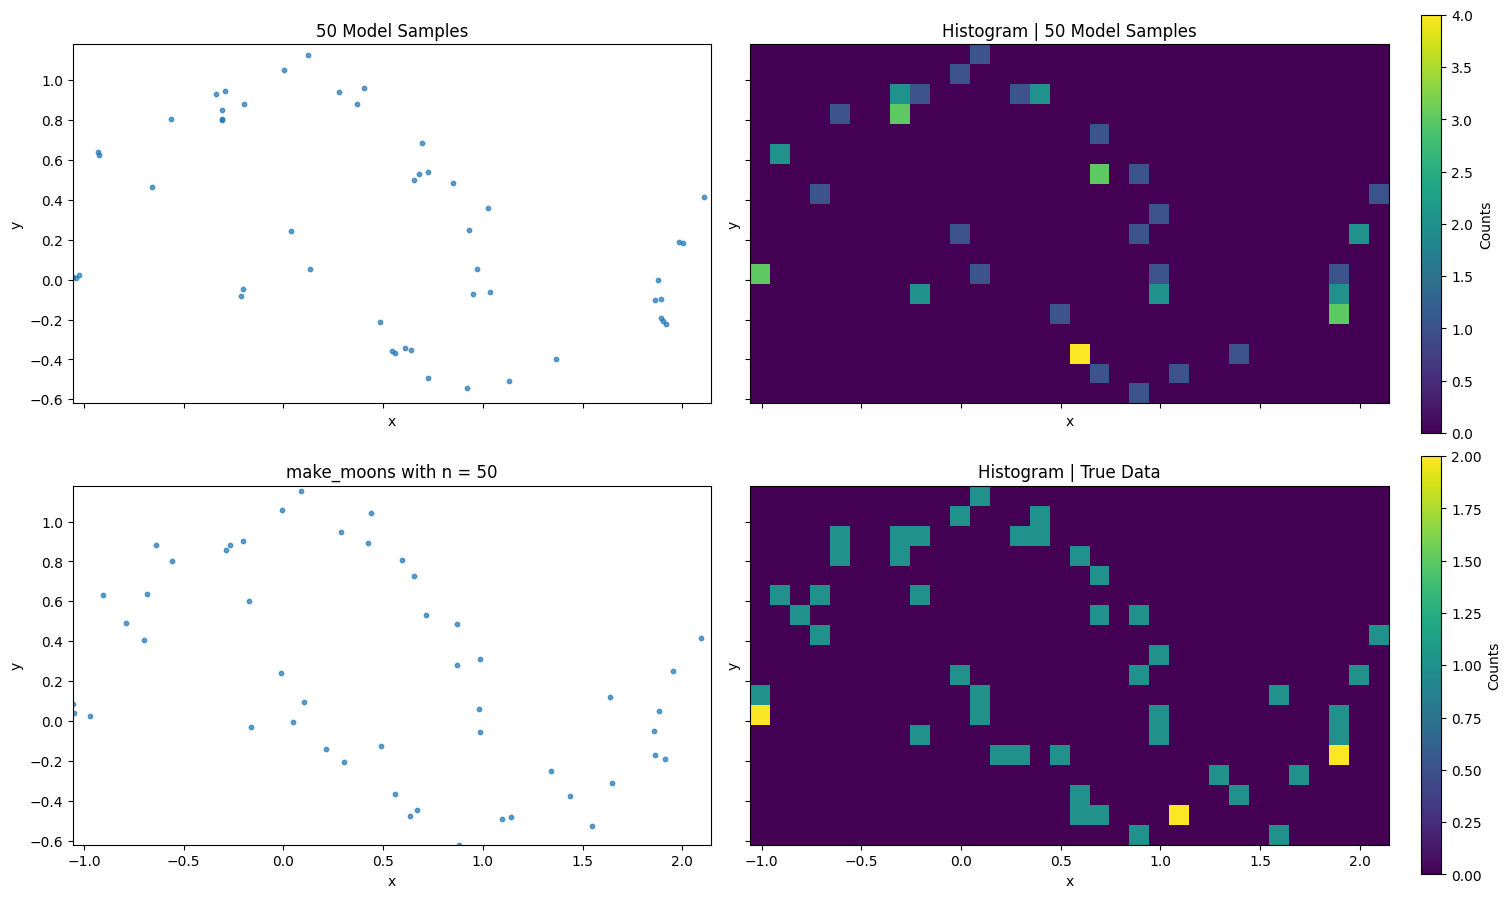

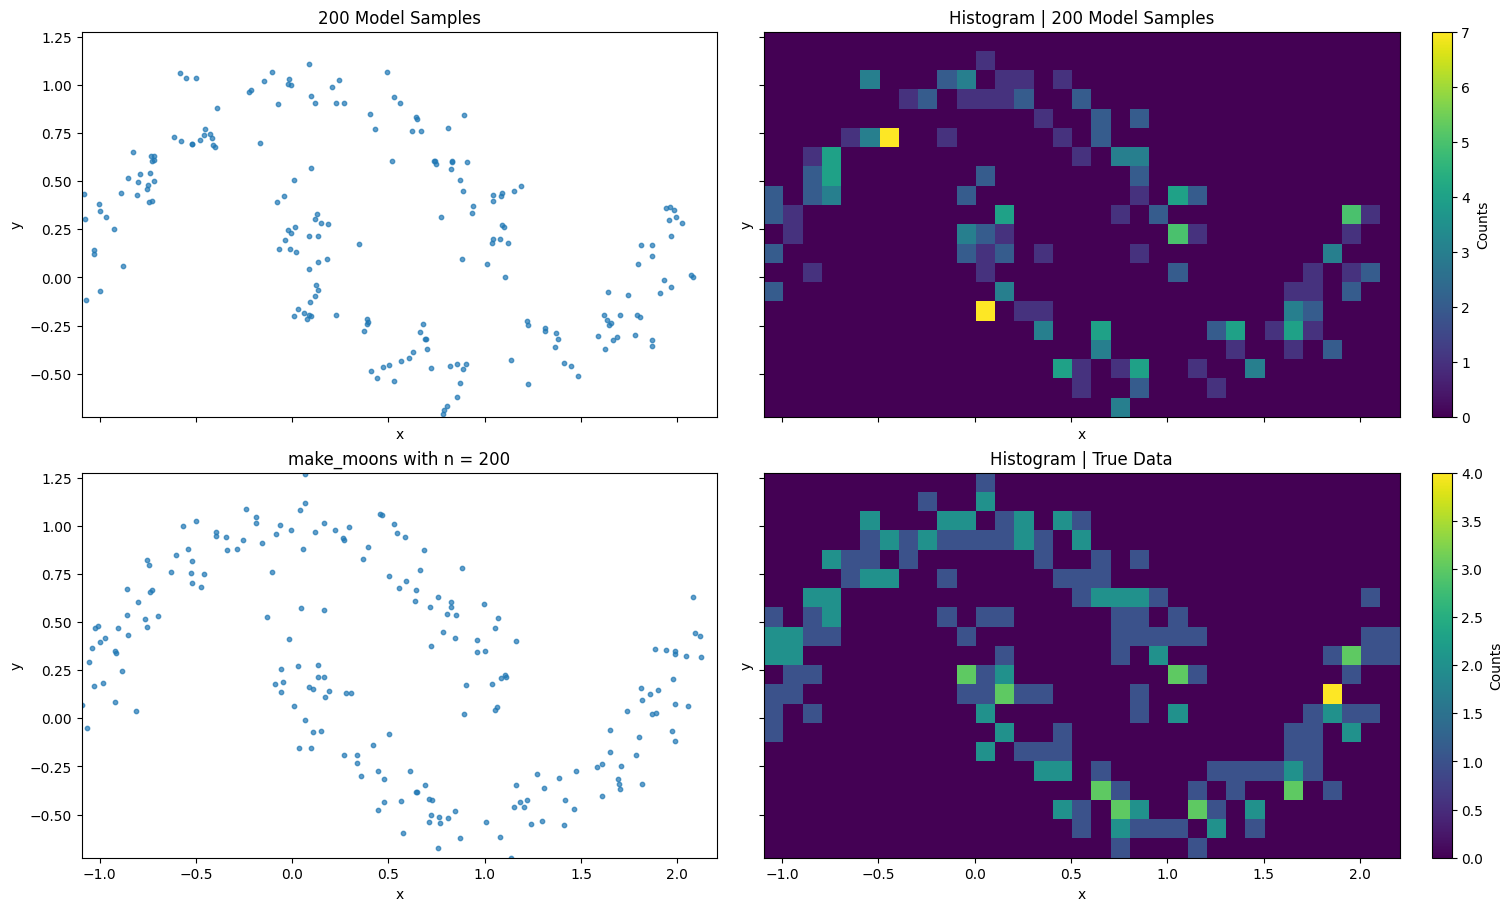

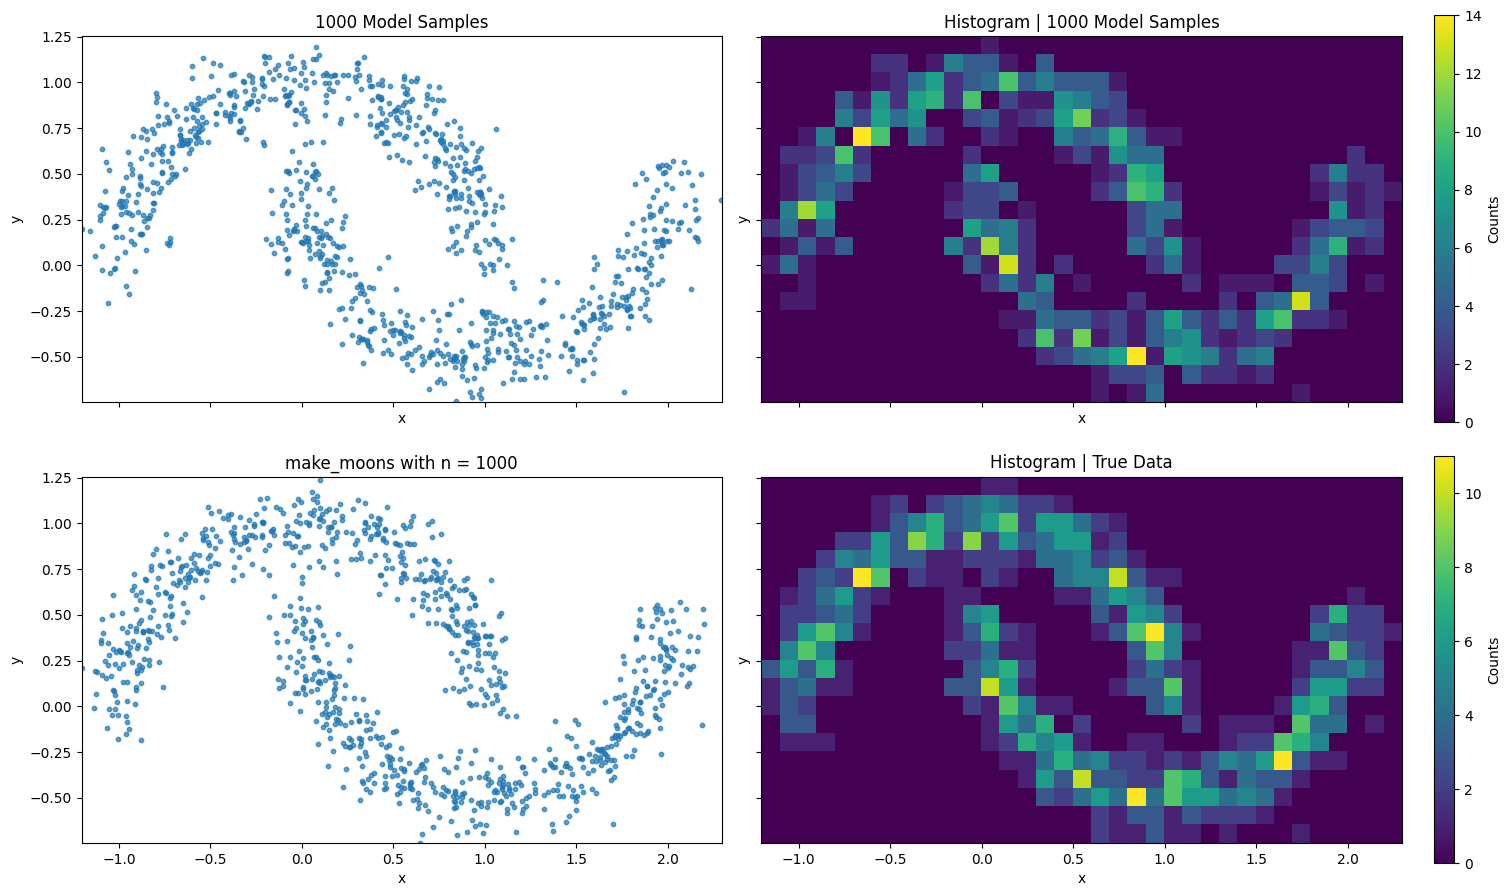

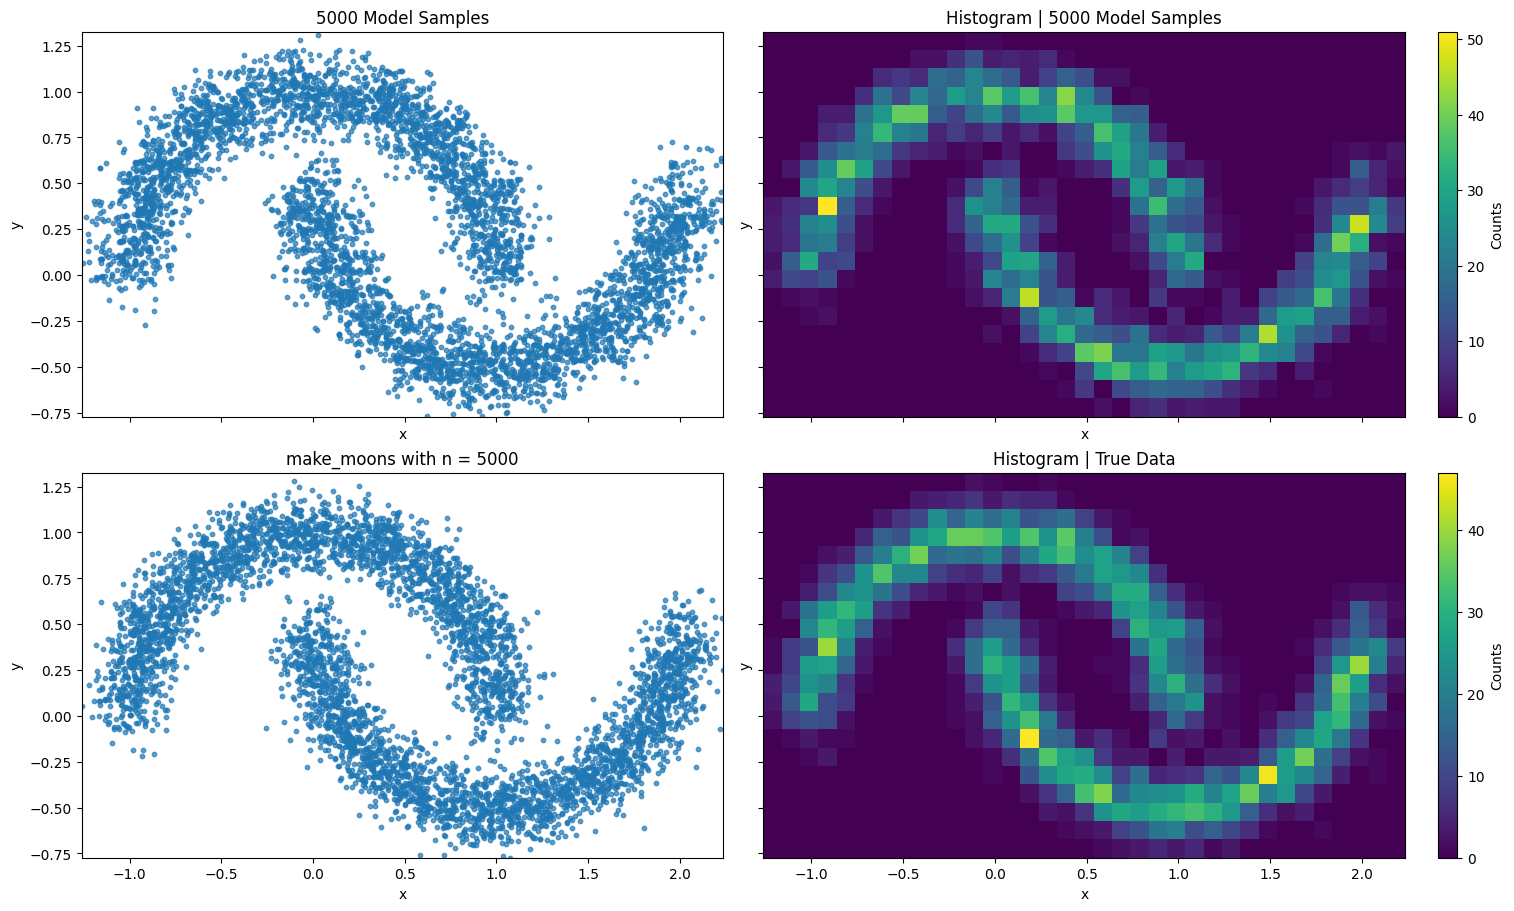

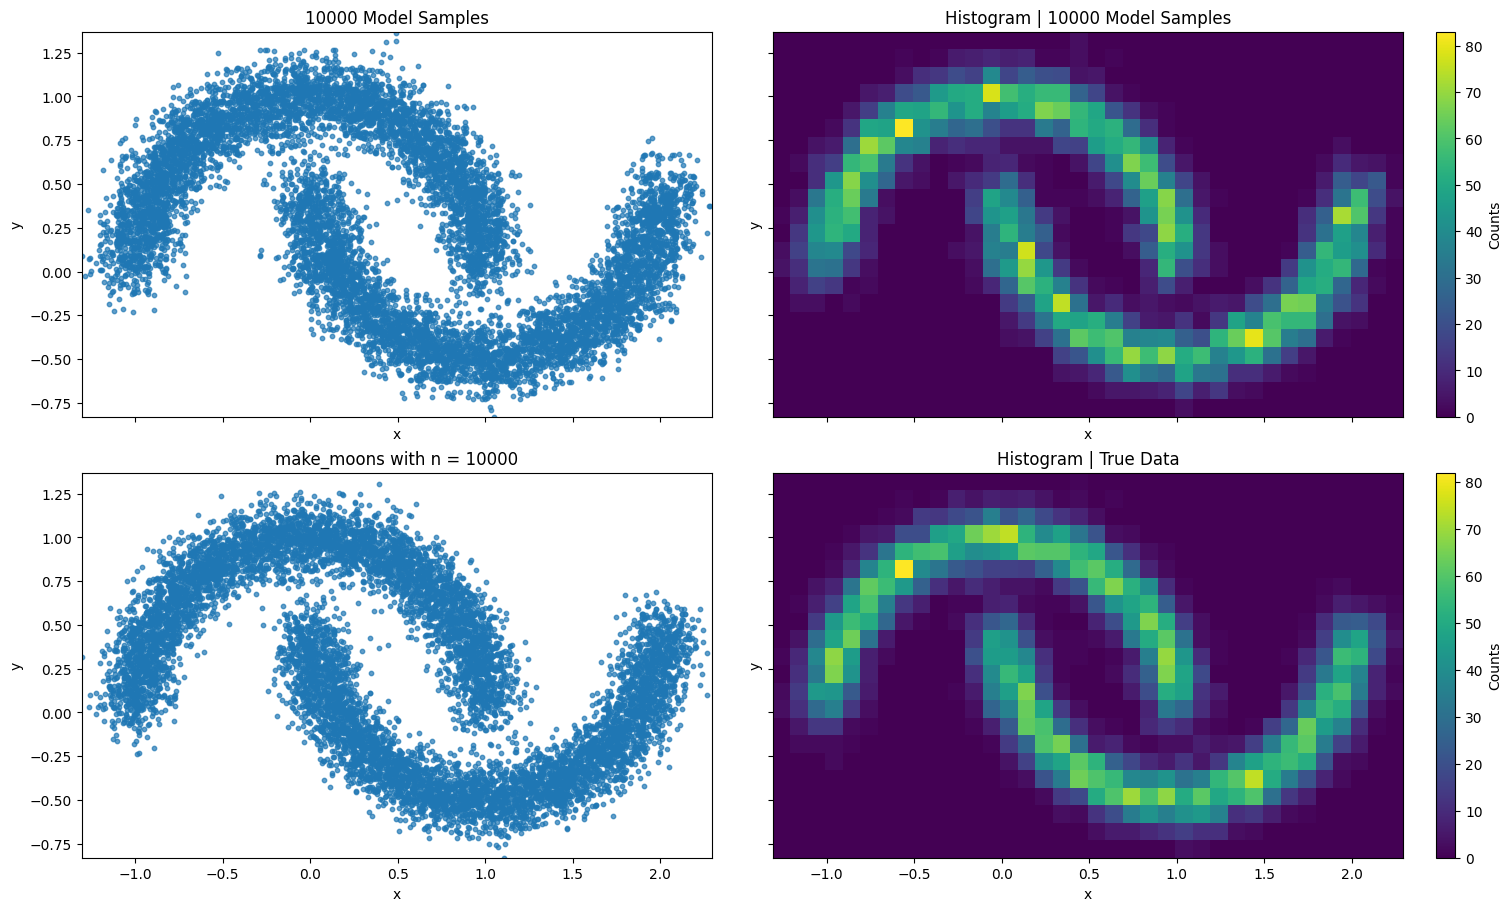

In [4]:
# Create moons datasets and try to fit models.
for n in [50, 200, 1000, 5000, 10000]:
    # Dataset.
    X, _ = make_moons(n_samples=n, noise=0.1)

    # Fit histogram model.
    model = Histogram2DModel(h=0.1, X=X)

    # Sample from the model.
    samples = model.sample(n)

    # Compute bin sizes for plotting.
    min_x = model.min_x
    min_y = model.min_y
    max_x = model.min_x + model.bins_x * model.h_x
    max_y = model.min_y + model.bins_y * model.h_y

    # Plot with sampled data, true data, 
    # and histograms of samples and true data.
    fig, axes = plt.subplots(
        2, 2, 
        figsize=(15, 9), 
        constrained_layout=True, 
        sharex=True, 
        sharey=True
    )
    
    # The model samples.
    axes[0,0].scatter(samples[:, 0], samples[:, 1], s=10, alpha=0.7)
    axes[0,0].set_title(f"{n} Model Samples")
    axes[0,0].set_xlabel("x")
    axes[0,0].set_ylabel("y")

    # The model samples histogram.
    h1 = axes[0,1].hist2d(
        samples[:, 0], 
        samples[:, 1], 
        bins=[model.bins_x, model.bins_y], 
        range=[[min_x, max_x], [min_y, max_y]]
    )
    axes[0,1].set_title(f"Histogram | {n} Model Samples")
    axes[0,1].set_xlabel("x")
    axes[0,1].set_ylabel("y")
    fig.colorbar(h1[3], ax=axes[0,1], label="Counts")

    # The true data.
    axes[1,0].scatter(X[:, 0], X[:, 1], s=10, alpha=0.7)
    axes[1,0].set_title(f"make_moons with n = {n}")
    axes[1,0].set_xlabel("x")
    axes[1,0].set_ylabel("y")

    # The true data histogram.
    h2 = axes[1,1].hist2d(
        X[:, 0], 
        X[:, 1], 
        bins=[model.bins_x, model.bins_y], 
        range=[[min_x, max_x], [min_y, max_y]]
    )
    axes[1,1].set_title("Histogram | True Data")
    axes[1,1].set_xlabel("x")
    axes[1,1].set_ylabel("y")
    fig.colorbar(h2[3], ax=axes[1,1], label="Counts")

    # Ensure equal aspect ratio.
    for ax in axes.flatten():
        ax.set_xlim(*[min_x, max_x])
        ax.set_ylim(*[min_y, max_y])
        ax.set_aspect('equal', adjustable='box')

    plt.show()

### Single Gaussian

#### Class

In [5]:
class SingleGaussianModel:
    
    def __init__(self, X=None):
        """
        Initializes the Model.

        Parameters
        ----------
        X : array-like, shape (n_samples, 2), optional
            Input data to fit the model. 
            If provided, the model is fitted during initialization.
        """

        # Mean.
        self.mu = None

        # Covariance Matrix.
        self.sigma = None

        if X is not None:
            self.fit(X)
    
    def fit(self, X):
        """
        Fits the model.

        Parameters
        ----------
        X : array-like, shape (n_samples, 2)
            Input data to fit the model.
        """
        
        # Calculate mean and covariance matrix.
        self.mu = np.mean(X, axis=0)
        self.sigma = np.cov(X, rowvar=False)

        return self

    def sample(self, n_samples):
        """
        Generates samples.

        Parameters
        ----------
        n_samples : int
            Number of samples.

        Returns
        -------
        samples : array-like, shape (n_samples, 2)
        """

        if self.mu is None or self.sigma is None:
            raise ValueError("Model must be fitted before sampling.")

        samples = np.random.multivariate_normal(self.mu, self.sigma, size=n_samples)

        return samples
    
    def score_samples(self, X):
        """
        Compute the log-likelihood of each sample.

        Parameters
        ----------
        X : array-like, shape (n_samples, 2)
            Input data.

        Returns
        -------
        log_likelihoods : array-like, shape (n_samples,)
            Log-likelihood of each sample.
        """

        if self.mu is None or self.sigma is None:
            raise ValueError("Model must be fitted before scoring.")

        log_likelihoods = np.zeros(len(X))

        d = X.shape[1]  # Dimension = 2.

        # Numerically more stable than np.linalg.inv.
        # Regularization to avoid singularity.
        eps = 1e-8
        L = np.linalg.cholesky(self.sigma + eps * np.eye(d))

        for i, s in enumerate(X):
            diff = s - self.mu
            y = np.linalg.solve(L, diff)
            maha = np.matmul(y, y)
            logdet = 2 * np.sum(np.log(np.diag(L)))
            log_likelihoods[i] = -0.5 * (d * np.log(2 * np.pi) + logdet + maha)

        return log_likelihoods


#### Test 1
---
Compare log-likelihoods, mean and covariance matrix with established sklearn class.

In [6]:
# Use sklearn's GaussianMixture for comparison.
from sklearn.mixture import GaussianMixture

# Fit both models to random data.
X = np.random.randn(100, 2)
m1 = SingleGaussianModel(X)
m2 = GaussianMixture(n_components=1).fit(X)

# Compute log-likelihoods.
s1 = m1.score_samples(X)
s2 = m2.score_samples(X)

# Print log-likelihoods for the first 10 samples.
for i in range(10):
    print(
        f"Sample {i}: SingleGaussianModel log-likelihood = {s1[i]:.4f},"
        f" GaussianMixture log-likelihood = {s2[i]:.4f}"
    )

# Compare means.
print("SingleGaussianModel Mean:", m1.mu)
print("GaussianMixture Mean:", m2.means_)

# Compare covariance matrices.
print("SingleGaussianModel Covariance:\n", m1.sigma)
print("GaussianMixture Covariance:\n", m2.covariances_[0])


Sample 0: SingleGaussianModel log-likelihood = -5.1968, GaussianMixture log-likelihood = -5.2194
Sample 1: SingleGaussianModel log-likelihood = -4.6052, GaussianMixture log-likelihood = -4.6219
Sample 2: SingleGaussianModel log-likelihood = -2.3830, GaussianMixture log-likelihood = -2.3772
Sample 3: SingleGaussianModel log-likelihood = -3.8475, GaussianMixture log-likelihood = -3.8565
Sample 4: SingleGaussianModel log-likelihood = -2.2251, GaussianMixture log-likelihood = -2.2177
Sample 5: SingleGaussianModel log-likelihood = -2.4078, GaussianMixture log-likelihood = -2.4023
Sample 6: SingleGaussianModel log-likelihood = -3.6095, GaussianMixture log-likelihood = -3.6162
Sample 7: SingleGaussianModel log-likelihood = -2.7268, GaussianMixture log-likelihood = -2.7245
Sample 8: SingleGaussianModel log-likelihood = -2.1579, GaussianMixture log-likelihood = -2.1499
Sample 9: SingleGaussianModel log-likelihood = -2.6381, GaussianMixture log-likelihood = -2.6349
SingleGaussianModel Mean: [ 0.

#### Test 2
---
Plots!

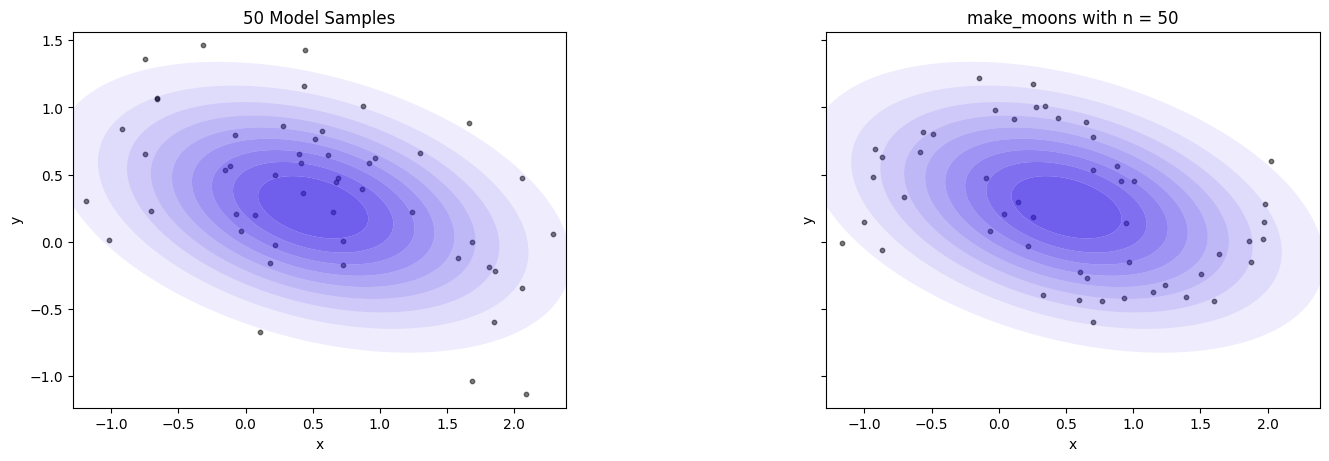

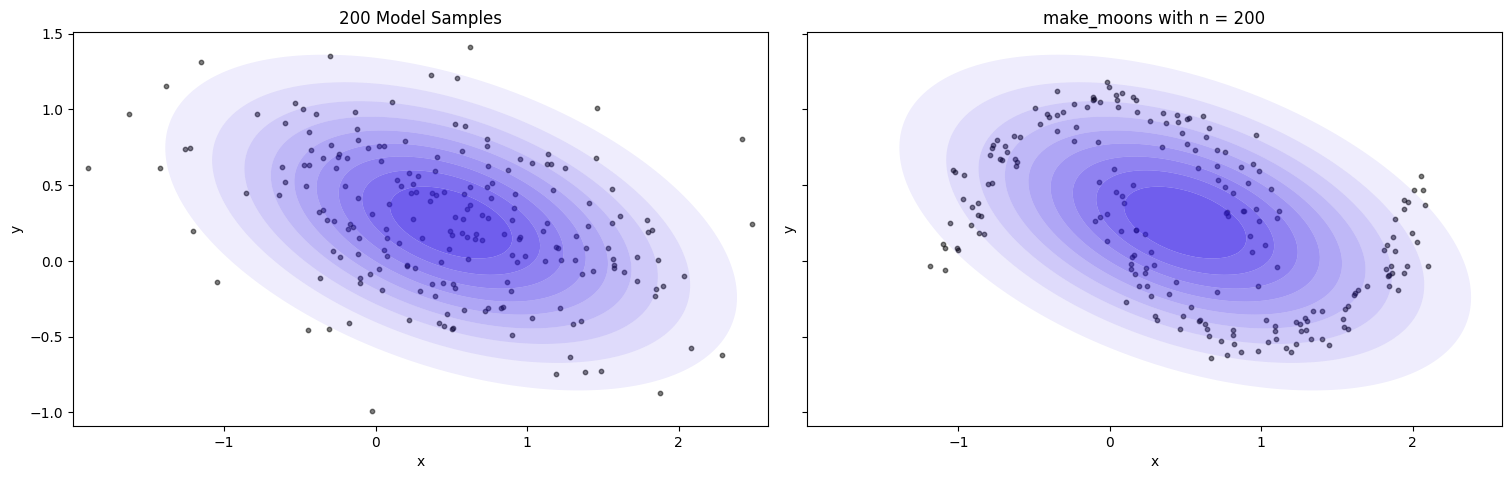

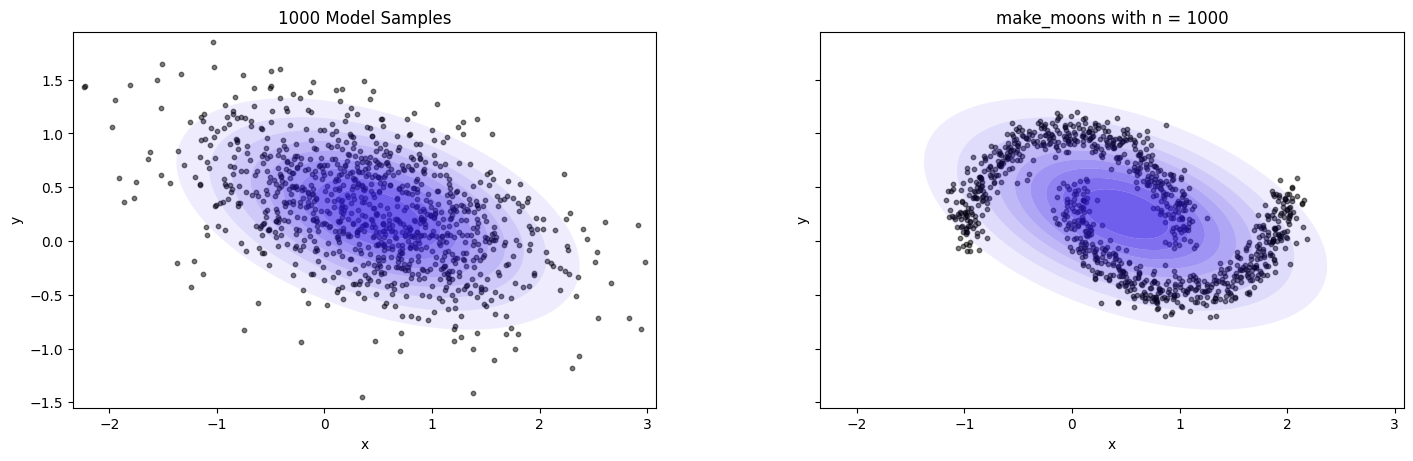

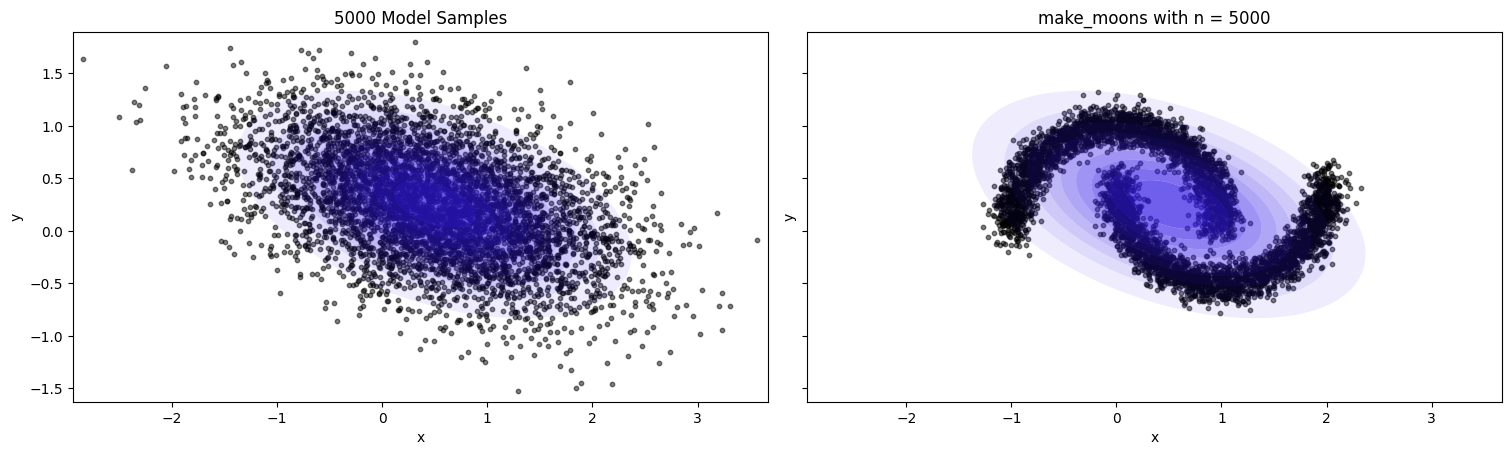

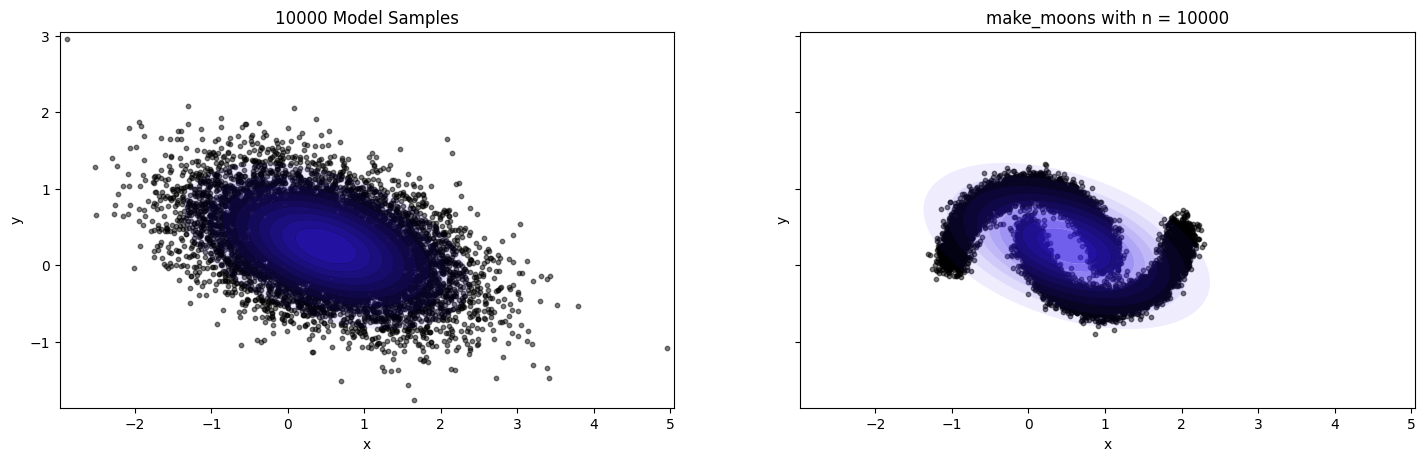

In [7]:
# Create moons datasets and try to fit models.
for n in [50, 200, 1000, 5000, 10000]:
    # Dataset without labels.
    X, _ = make_moons(n_samples=n, noise=0.1)

    # Fit single gaussian model.
    model = SingleGaussianModel(X)

    # Sample from the model.
    samples = model.sample(n)

    # Plot limits.
    all_x = np.concatenate((X, samples), axis=0)
    min_x = all_x[:, 0].min() - 0.1
    min_y = all_x[:, 1].min() - 0.1
    max_x = all_x[:, 0].max() + 0.1
    max_y = all_x[:, 1].max() + 0.1

    # Build grid for contour plot.
    x = np.linspace(model.mu[0] - 4, model.mu[0] + 4, 300)
    y = np.linspace(model.mu[1] - 4, model.mu[1] + 4, 300)
    X_grid, Y_grid = np.meshgrid(x, y)
    Z = multivariate_normal(mean=model.mu, cov=model.sigma).pdf(np.dstack([X_grid, Y_grid]))

    # Number of contour levels.
    N = 10
    levels = np.linspace(Z.min(), Z.max(), N + 1)

    # Color of the levels.
    alphas = np.linspace(0, 0.7, N)
    colors = [(0.2, 0.1, 0.9, a) for a in alphas] 

    # Plot with sampled data and true data.
    fig, axes = plt.subplots(
        1, 2, 
        figsize=(15, 4.5), 
        constrained_layout=True, 
        sharex=True, 
        sharey=True
    )
    
    # The model samples.
    axes[0].scatter(samples[:, 0], samples[:, 1], s=10, c="black", alpha=0.5)
    axes[0].contourf(
        X_grid, Y_grid, Z,
        levels=levels,
        colors=colors,
        antialiased=True
    )
    axes[0].set_title(f"{n} Model Samples")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")

    # The true data.
    axes[1].scatter(X[:, 0], X[:, 1], s=10, c="black", alpha=0.5)
    cs = axes[1].contourf(
        X_grid, Y_grid, Z,
        levels=levels,
        colors=colors,
        antialiased=True
    )
    axes[1].set_title(f"make_moons with n = {n}")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")

    # Ensure equal aspect ratio.
    for ax in axes:
        ax.set_xlim(*[min_x, max_x])
        ax.set_ylim(*[min_y, max_y])
        ax.set_aspect('equal', adjustable='box')

    plt.show()


    




---
### GMM
---

<div style="color: green; font-weight: bold">
- An option to change the numbers of components dynamically was included, but not visualised later on. 

- MORE COMMENtS?
</div>

#### Class

In [8]:
class GMM:
    
    def __init__(self, n_components=1, X=None):
        """
        Initializes the Model.

        Parameters
        ----------
        n_components : int, optional
            Number of mixture components.
        X : array-like, shape (n_samples, 2), optional
            Input data to fit the model. 
            If provided, the model is fitted during initialization.
        """

        # Number of components.
        self.n_components = n_components

        # Means.
        self.mus = None

        # Covariance Matrices.
        self.sigmas = None

        # Mixing coefficients.
        self.pis = None

        if X is not None:
            self.fit(X)

    def _gaussian_pdf_2d(self, X, mu, sigma):

        if X.ndim == 1:
            X = X[None, :]  # allow a single point.

        d = mu.shape[0]  # (2).

        # Cholesky factorization.
        L = np.linalg.cholesky(sigma)
        diff = X - mu
        y = np.linalg.solve(L, diff.T)
        quad = np.sum(y * y, axis=0)

        # log normalizer using Cholesky:
        # sqrt(det(sigma)) = prod(diag(L))
        # denom = (2pi)^(d/2) * sqrt(det(sigma))
        log_denom = 0.5 * d * np.log(2.0 * np.pi) + np.sum(np.log(np.diag(L)))

        log_pdf = -0.5 * quad - log_denom
        return np.exp(log_pdf)

    def fit(self, X, steps=250, tol=1e-8):
        """
        Fits the model using EM algorithm.

        Parameters
        ----------
        X : array-like, shape (n_samples, 2)
            Input data to fit the model.
        steps : int, optional
            Maximum number of EM steps.
        tol : float, optional
            Convergence tolerance.
        """
        
        # Initialize parameters.
        n, d = X.shape # n: number of samples, d: dimension (2).
        mus = X[np.random.choice(n, self.n_components, replace=False)]
        pis = np.full(self.n_components, 1.0 / self.n_components)
        sigmas = np.array([np.eye(d) for _ in range(self.n_components)])

        gammas = np.zeros((n, self.n_components))

        # Log-likelihood for convergence check.
        prev_ll = -np.inf

        # Small constant to avoid singularity.
        eps = 1e-8


        # EM steps.
        for step in range(steps):
            # E-step:
            for k in range(self.n_components):
                sk = sigmas[k] + eps * np.eye(d)  # Regularization to avoid singularity.
                gammas[:, k] = pis[k] * self._gaussian_pdf_2d(X, mus[k], sk)
            norm = gammas.sum(axis=1, keepdims=True) + eps
            like_ = gammas.copy()
            gammas = gammas / norm
            Nk = gammas.sum(axis=0)

            # M-step:
            pis = Nk / n
            mus = (gammas.T @ X) / Nk[:, None]
            for k in range(self.n_components):
                diff = X - mus[k]
                sigmas[k] = (diff.T * gammas[:, k]) @ diff / Nk[k] + eps * np.eye(d)

            like = like_.sum(axis=1) + eps
            ll = np.sum(np.log(like))
            if np.abs(ll - prev_ll) < tol:
                break
            prev_ll = ll

        # Fitted parameters.
        pis /= pis.sum()
        self.mus = mus
        self.sigmas = sigmas
        self.pis = pis

        return self

    def sample(self, n_samples):
        """
        Generates samples.

        Parameters
        ----------
        n_samples : int
            Number of samples.

        Returns
        -------
        samples : array-like, shape (n_samples, 2)
        """

        if self.mus is None or self.sigmas is None or self.pis is None:
            raise ValueError("Model must be fitted before sampling.")

        samples_list = np.zeros((n_samples, 2))

        for i in range(n_samples):
            # Choose a component based on mixing coefficients.
            component = np.random.choice(self.n_components, p=self.pis)

            # Sample from the chosen Gaussian component.
            samples = np.random.multivariate_normal(self.mus[component], self.sigmas[component])
            samples_list[i] = samples

        return samples_list
    
    def score_samples(self, X):
        """
        Compute the log-likelihood of each sample.

        Parameters
        ----------
        X : array-like, shape (n_samples, 2)
            Input data.

        Returns
        -------
        log_likelihoods : array-like, shape (n_samples,)
            Log-likelihood of each sample.
        """

        if self.mus is None or self.sigmas is None or self.pis is None:
            raise ValueError("Model must be fitted before scoring.")

        eps = 1e-8  # small constant.
        
        # Vectorized computation.
        log_likelihoods = np.zeros(len(X))
        
        for k in range(self.n_components):
            # Regularization to avoid singularity.
            sig = self.sigmas[k] + eps * np.eye(X.shape[1])

            pdf_values = self._gaussian_pdf_2d(X, self.mus[k], sig)
            log_likelihoods += self.pis[k] * pdf_values
            
        log_likelihoods = np.log(log_likelihoods + eps)

        return log_likelihoods

#### Test

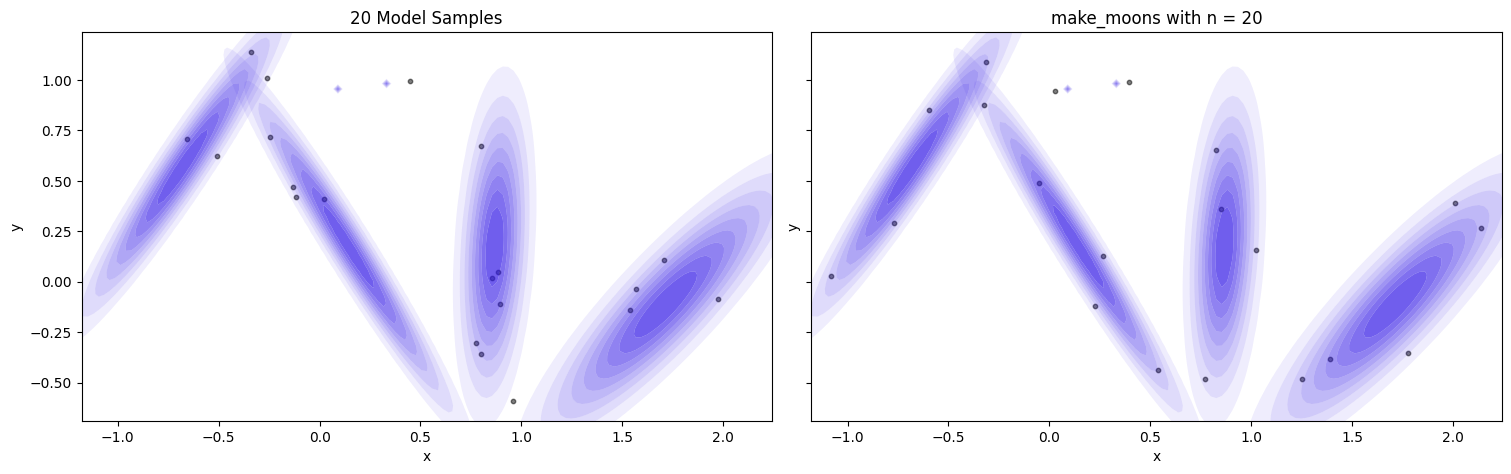

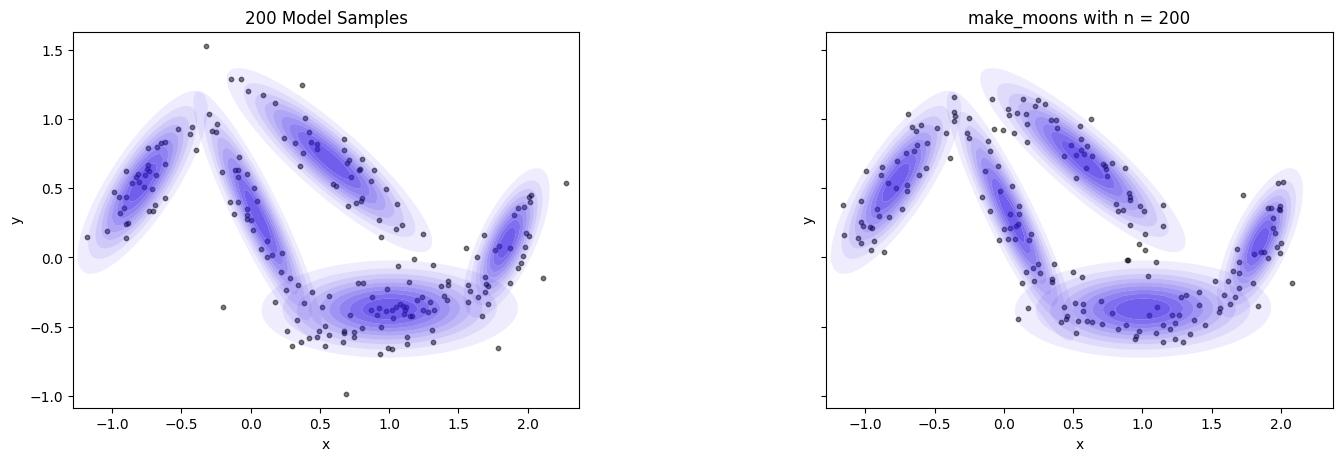

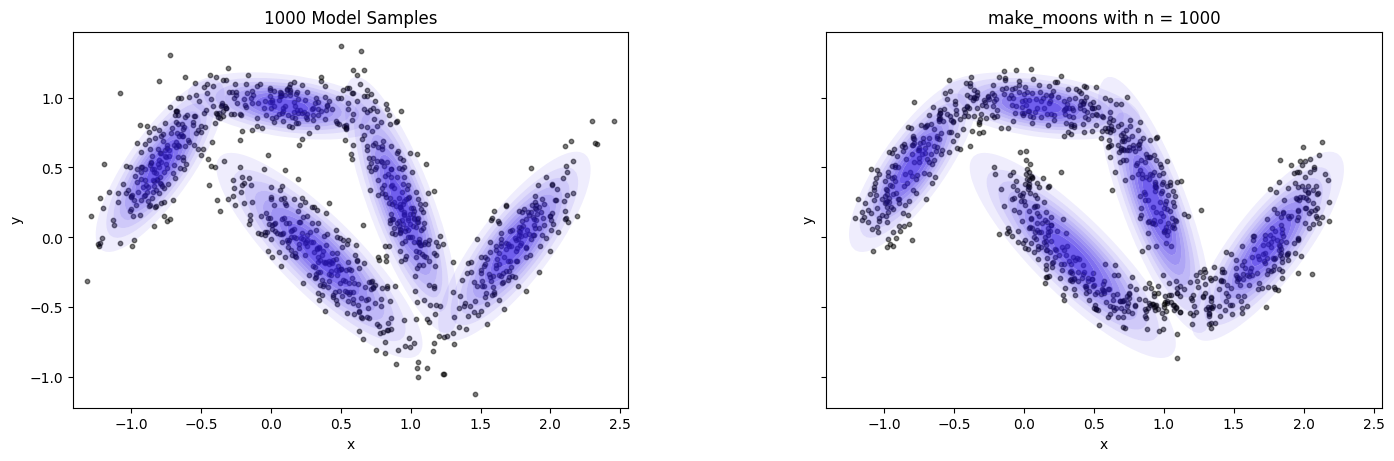

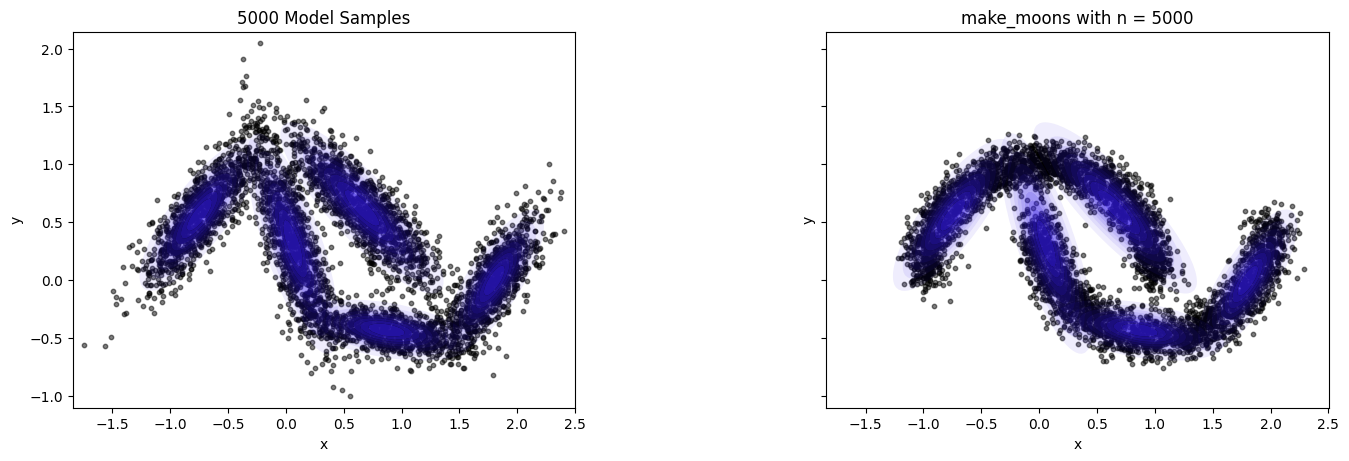

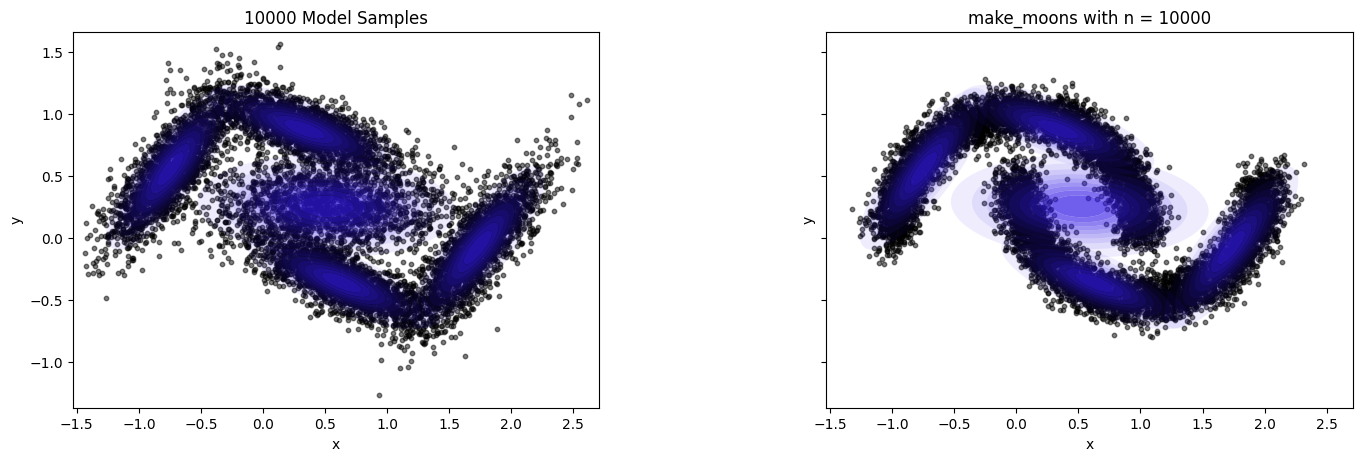

In [9]:
# Create moons datasets and try to fit models.
for n in [20, 200, 1000, 5000, 10000]:
    # Dataset without labels.
    X, _ = make_moons(n_samples=n, noise=0.1)

    # Fit model.
    model = GMM(n_components=5).fit(X)

    # Sample from the model.
    samples = model.sample(n)

    # Plot limits.
    all_x = np.concatenate((X, samples), axis=0)
    min_x = all_x[:, 0].min() - 0.1
    min_y = all_x[:, 1].min() - 0.1
    max_x = all_x[:, 0].max() + 0.1
    max_y = all_x[:, 1].max() + 0.1

    # Build grids for contour plots.
    x = [np.linspace(mu[0] - 4, mu[0] + 4, 300) for mu in model.mus]
    y = [np.linspace(mu[1] - 4, mu[1] + 4, 300) for mu in model.mus]
    X_grids = []
    Y_grids = []
    Zs = []
    for i in range(model.n_components):
        X_grid, Y_grid = np.meshgrid(x[i], y[i])
        X_grids.append(X_grid)
        Y_grids.append(Y_grid)
        Z = multivariate_normal(mean=model.mus[i], cov=model.sigmas[i]).pdf(np.dstack([X_grid, Y_grid]))
        Zs.append(Z)

    # Number of contour levels.
    N = 10
    levels = [np.linspace(Z.min(), Z.max(), N + 1) for Z in Zs]

    # Color of the levels.
    alphas = np.linspace(0, 0.7, N)
    colors = [(0.2, 0.1, 0.9, a) for a in alphas] 

    # Plot with sampled data and true data.
    fig, axes = plt.subplots(
        1, 2, 
        figsize=(15, 4.5), 
        constrained_layout=True, 
        sharex=True, 
        sharey=True
    )
    
    # The model samples.
    axes[0].scatter(samples[:, 0], samples[:, 1], s=10, c="black", alpha=0.5)
    for i in range(model.n_components):
        X_grid = X_grids[i]
        Y_grid = Y_grids[i]
        Z = Zs[i]
        axes[0].contourf(
            X_grid, Y_grid, Z,
            levels=levels[i],
            colors=colors,
            antialiased=True
        )
    axes[0].set_title(f"{n} Model Samples")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")

    # The true data.
    axes[1].scatter(X[:, 0], X[:, 1], s=10, c="black", alpha=0.5)
    for i in range(model.n_components):
        X_grid = X_grids[i]
        Y_grid = Y_grids[i]
        Z = Zs[i]
        axes[1].contourf(
            X_grid, Y_grid, Z,
            levels=levels[i],
            colors=colors,
            antialiased=True
        )
    axes[1].set_title(f"make_moons with n = {n}")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")

    # Ensure equal aspect ratio.
    for ax in axes:
        ax.set_xlim(*[min_x, max_x])
        ax.set_ylim(*[min_y, max_y])
        ax.set_aspect('equal', adjustable='box')

    plt.show()

---
### KDE
---

#### Class

In [10]:
class KDEGaussian:
    def __init__(self, h=0.1, X=None):
        """
        Initializes the KDE with a Gaussian kernel.

        Parameters
        ----------
        h : float, optional
            Bandwidth.
        X : array-like, shape (n_samples, 2), optional
            Input data to fit the model.
        """
        self.h = h
        self.mu = X
        self.sigma = h**2 * np.eye(2)

    def fit(self, X):
        """
        Fits the model by storing the data points.

        Parameters
        ----------
        X : array-like, shape (n_samples, 2)
            Input data to fit the model.
        """

        self.mu = X

        return self

    def sample(self, n_samples):
        """
        Generates samples.

        Parameters
        ----------
        n_samples : int
            Number of samples.

        Returns
        -------
        samples : array-like, shape (n_samples, 2)
        """

        if self.mu is None:
            raise ValueError("Model must be fitted before sampling.")

        n_mu = self.mu.shape[0]
        samples = np.zeros((n_samples, 2))

        for i in range(n_samples):
            # Randomly choose a data point.
            idx = np.random.randint(n_mu)
            mu = self.mu[idx]

            # Sample from the Gaussian centered at the chosen data point.
            sample = np.random.multivariate_normal(mu, self.sigma)
            samples[i] = sample

        return samples
    
    def score_samples(self, X):
        """
        Compute the log-likelihood of each sample.

        Parameters
        ----------
        X : array-like, shape (n_samples, 2)
            Input data.

        Returns
        -------
        log_likelihoods : array-like, shape (n_samples,)
            Log-likelihood of each sample.
        """

        if self.mu is None:
            raise ValueError("Model must be fitted before scoring.")

        log_likelihoods = np.zeros(len(X))
        
        n = self.mu.shape[0]
        if self.h <= 0:
            raise ValueError("Bandwidth h must positive")

        # Pairwise squared distances.
        # sq_ij = ||x_i||^2 + ||mu_j||^2 - 2 x_i mu_j
        X2 = np.sum(X * X, axis=1)[:, None] # (N,1)
        MU2 = np.sum(self.mu * self.mu, axis=1)[None, :] # (1,n)
        sq = X2 + MU2 - 2.0 * (X @ self.mu.T) # (N,n)
        # Guard against tiny negative values.
        np.maximum(sq, 0.0, out=sq)

        # Exponent arguments.
        # a_ij = - ||x_i - mu_j||^2 / (2 h^2)
        a = -0.5 * sq / (self.h ** 2) # (N,n)

        # Log-sum-exp along axis=1
        m = np.max(a, axis=1, keepdims=True) # (N,1)
        lse = (m + np.log(np.sum(np.exp(a - m), axis=1, keepdims=True)))[:, 0] # (N,)

        # Constant term.
        # -(d/2)log(2π) - d log h
        # With d=2 -> -log(2π) - 2 log h
        const = -np.log(2.0 * np.pi) - 2.0 * np.log(self.h)

        return const + lse - np.log(n)

#### Test

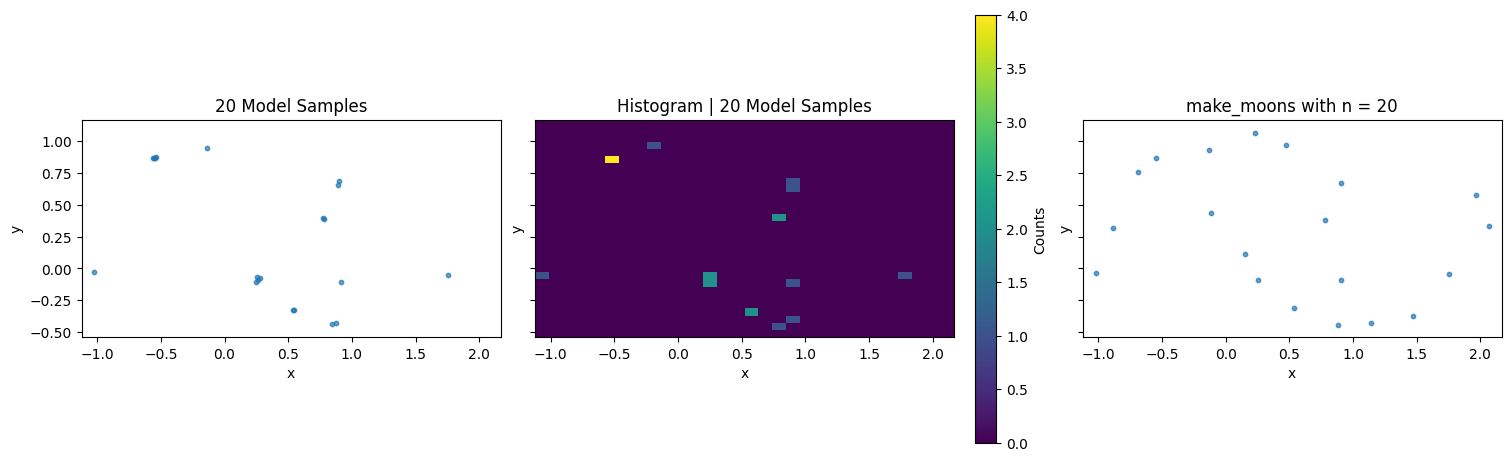

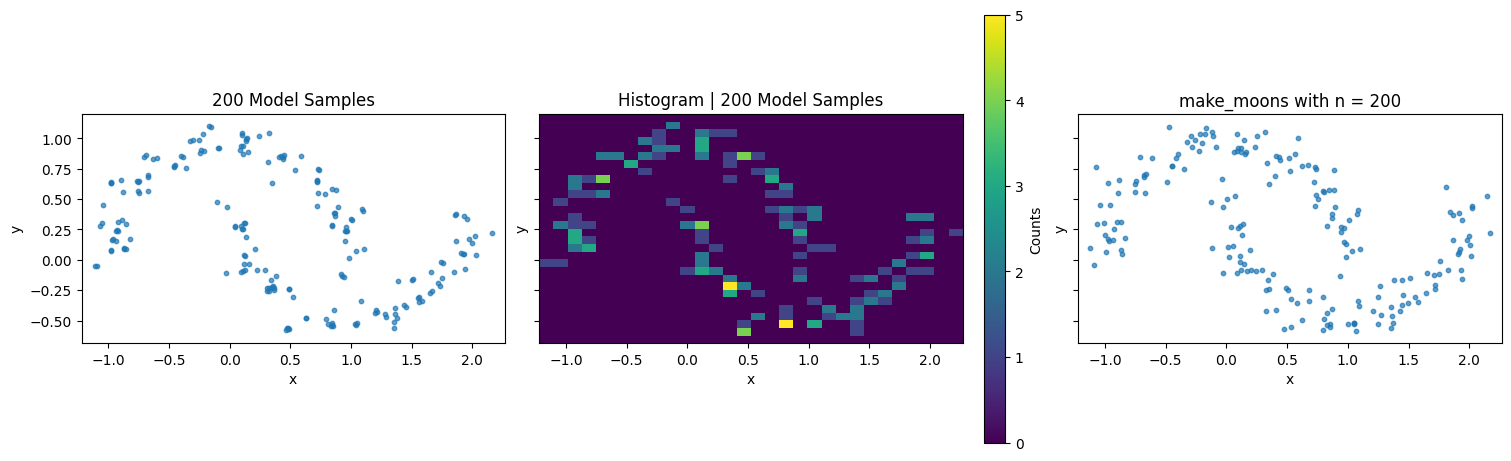

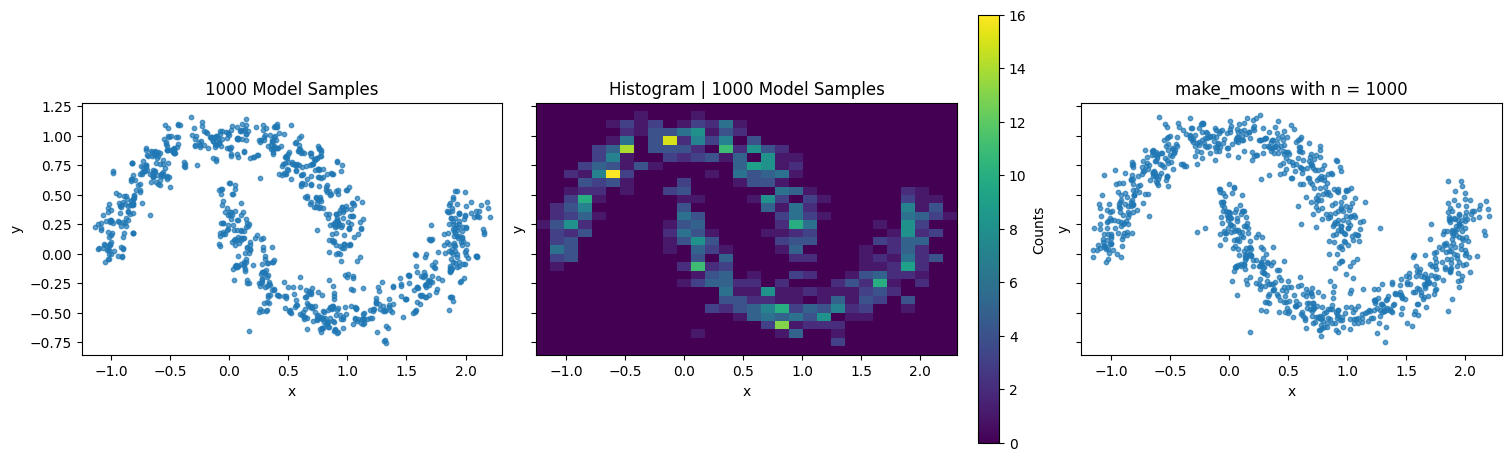

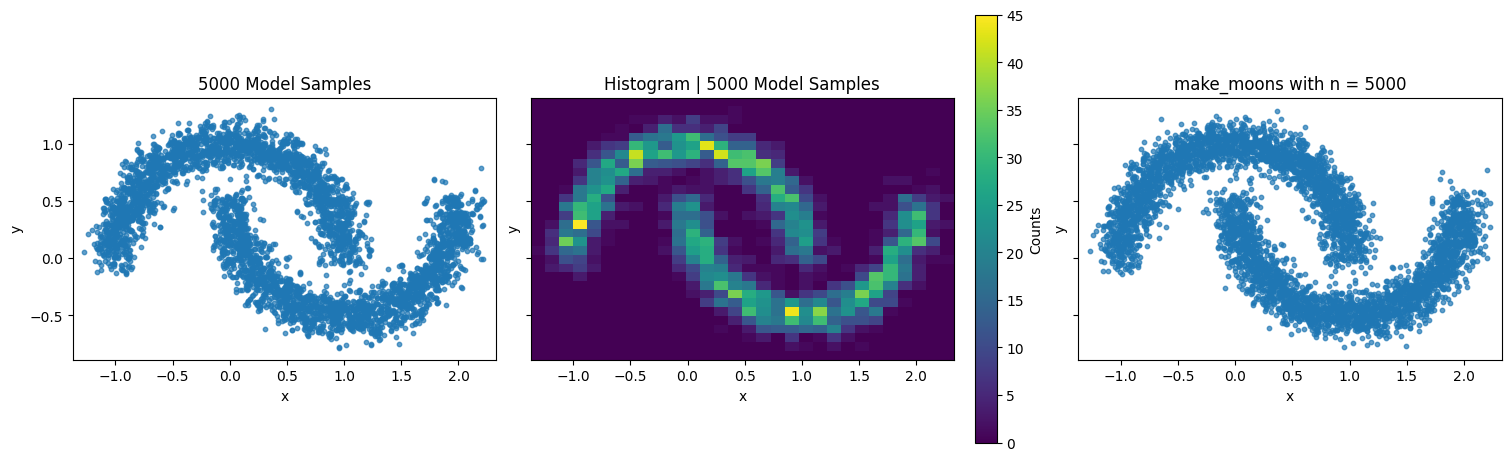

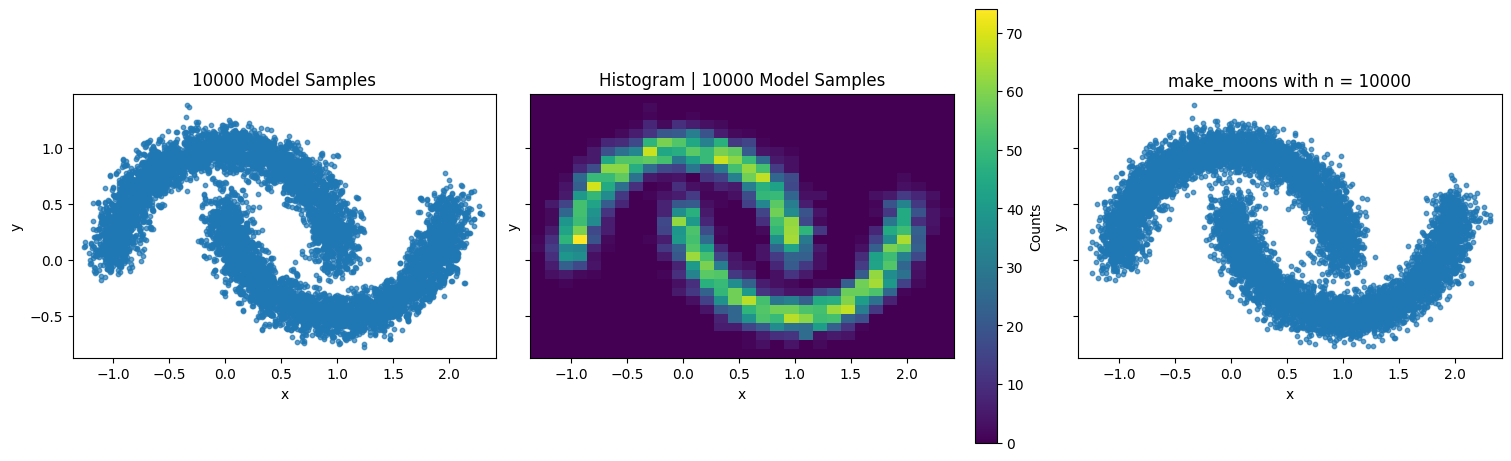

In [11]:
# Create moons datasets and try to fit models.
for n in [20, 200, 1000, 5000, 10000]:
    # Dataset without labels.
    X, _ = make_moons(n_samples=n, noise=0.1)

    # Fit model.
    model = KDEGaussian(h=0.01).fit(X)

    # Sample from the model.
    samples = model.sample(n)

    # Plot limits.
    all_x = np.concatenate((X, samples), axis=0)
    min_x = all_x[:, 0].min() - 0.1
    min_y = all_x[:, 1].min() - 0.1
    max_x = all_x[:, 0].max() + 0.1
    max_y = all_x[:, 1].max() + 0.1

    # Plot with sampled data, sample histogram, and true data.
    fig, axes = plt.subplots(
        1, 3, 
        figsize=(15, 4.5), 
        constrained_layout=True, 
        sharex=True, 
        sharey=True
    )
    
    # The model samples.
    axes[0].scatter(samples[:, 0], samples[:, 1], s=10, alpha=0.7)
    axes[0].set_title(f"{n} Model Samples")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")

    # The sample histogram.
    h1 = axes[1].hist2d(
        samples[:, 0], 
        samples[:, 1], 
        bins=30, 
        range=[[min_x, max_x], [min_y, max_y]]
    )
    axes[1].set_title(f"Histogram | {n} Model Samples")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    fig.colorbar(h1[3], ax=axes[1], label="Counts")

    # The true data.
    axes[2].scatter(X[:, 0], X[:, 1], s=10, alpha=0.7)
    axes[2].set_title(f"make_moons with n = {n}")
    axes[2].set_xlabel("x")
    axes[2].set_ylabel("y")

    # Ensure equal aspect ratio.
    for ax in axes:
        ax.set_xlim(*[min_x, max_x])
        ax.set_ylim(*[min_y, max_y])
        ax.set_aspect('equal', adjustable='box')

    plt.show()

---
### $MMD^2$
---

<div style="color: green; font-weight: bold">

- sklearn.metrics.pairwise.euclidean_distance() function is used for distance calculations. 
There is no explicit implementation of expansion of the squared norm.

- mmd() is implemented with essentially the same logic as the given solution, only difference is that single vectors for each dimension are used instead of a matrix.

- No option for averaging the MMD^2 over multiple data sets is included. 

  This would have been a nice extra, but the individual models can still be evaluated relative to each other.
</div>

In [12]:
def se(x, x_prime, h):
    """
    Squared Exponential Kernel.

    Parameters
    ----------
    x : array-like, shape (d,)
        First input.
    x_prime : array-like, shape (d,)
        Second input.
    h : float
        Bandwidth.

    Returns
    -------
    k : float
        Kernel value.
    """

    # Distance matrix.
    D_sq = euclidean_distances(x, x_prime, squared=True)
    np.maximum(D_sq, 0.0, out=D_sq)  # Guard against tiny negative values.
    k = np.exp(-0.5 * D_sq / (h ** 2))

    return k

def imq(x, x_prime, h):
    """
    Inverse Multi-Quadratic Kernel.

    Parameters
    ----------
    x : array-like, shape (d,)
        First input vector.
    x_prime : array-like, shape (d,)
        Second input vector.
    h : float
        Bandwidth.

    Returns
    -------
    k : float
        Kernel value.
    """

    D_sq = euclidean_distances(x, x_prime, squared=True)
    np.maximum(D_sq, 0.0, out=D_sq)  # Guard against tiny negative values.
    k = 1.0 / np.sqrt(1 + D_sq / (h ** 2))

    return k

def mmd_2(x, x_prime, h, k):
    """
    Computes the squared Maximum Mean Discrepancy (MMD^2)
    between two samples x and x_prime using kernel k.

    Parameters
    ----------
    x : array-like, shape (n_samples_x, d)
        First set of samples.
    x_prime : array-like, shape (n_samples_x_prime, d)
        Second set of samples.
    h : float
        Bandwidth for the kernel.
    k : callable
        Kernel function.

    Returns
    -------
    mmd2 : float
        Squared MMD value.
    """

    n = x.shape[0]
    m = x_prime.shape[0]

    if n < 2 or m < 2:
        raise ValueError("Each sample must contain at least two points.")

    K_xx = k(x, x, h)
    K_yy = k(x_prime, x_prime, h)
    K_xy = k(x, x_prime, h)

    sum_xx = (np.sum(K_xx) - np.trace(K_xx)) / (n * (n - 1))
    sum_yy = (np.sum(K_yy) - np.trace(K_yy)) / (m * (m - 1))
    sum_xy = np.mean(K_xy)

    mmd_sq = sum_xx + sum_yy - 2 * sum_xy

    return mmd_sq

---
#### Play with kernel bandwidth:
---

In [13]:
model_hist = Histogram2DModel(h=0.1)
model_gauss = SingleGaussianModel()
model_gmm = GMM(n_components=10)
model_kde = KDEGaussian(h=0.1)

# Models and Dataset to test on.
X, _ = make_moons(n_samples=1000, noise=0.1)
models = [
    model_hist.fit(X), 
    model_gauss.fit(X), 
    model_gmm.fit(X), 
    model_kde.fit(X)
]


# Possible bandwidths.
for b in [0.2, 0.6, 0.9, 1.2]:
    print(f"Bandwidth h = {b}\n")
    for model in models:
        samples = model.sample(1000)
        mmd2_se = mmd_2(X, samples, h=b, k=se)
        mmd2_imq = mmd_2(X, samples, h=b, k=imq)
        print(
            f"Model: {model.__class__.__name__}, "
            f"MMD^2 (SE) = {mmd2_se:.6f}, MMD^2 (IMQ) = {mmd2_imq:.6f}"
        )
    print(f"\n---\n")

Bandwidth h = 0.2

Model: Histogram2DModel, MMD^2 (SE) = -0.000926, MMD^2 (IMQ) = -0.000857
Model: SingleGaussianModel, MMD^2 (SE) = 0.025972, MMD^2 (IMQ) = 0.018109
Model: GMM, MMD^2 (SE) = 0.000299, MMD^2 (IMQ) = -0.000243
Model: KDEGaussian, MMD^2 (SE) = 0.000005, MMD^2 (IMQ) = -0.000170

---

Bandwidth h = 0.6

Model: Histogram2DModel, MMD^2 (SE) = -0.000981, MMD^2 (IMQ) = -0.000644
Model: SingleGaussianModel, MMD^2 (SE) = 0.014519, MMD^2 (IMQ) = 0.009397
Model: GMM, MMD^2 (SE) = -0.000028, MMD^2 (IMQ) = -0.000029
Model: KDEGaussian, MMD^2 (SE) = -0.001010, MMD^2 (IMQ) = -0.000623

---

Bandwidth h = 0.9

Model: Histogram2DModel, MMD^2 (SE) = -0.000298, MMD^2 (IMQ) = -0.000188
Model: SingleGaussianModel, MMD^2 (SE) = 0.006280, MMD^2 (IMQ) = 0.005356
Model: GMM, MMD^2 (SE) = -0.000970, MMD^2 (IMQ) = -0.000615
Model: KDEGaussian, MMD^2 (SE) = 0.000000, MMD^2 (IMQ) = -0.000061

---

Bandwidth h = 1.2

Model: Histogram2DModel, MMD^2 (SE) = -0.000731, MMD^2 (IMQ) = -0.000484
Model: Sing

---
#### Histogram2DModel

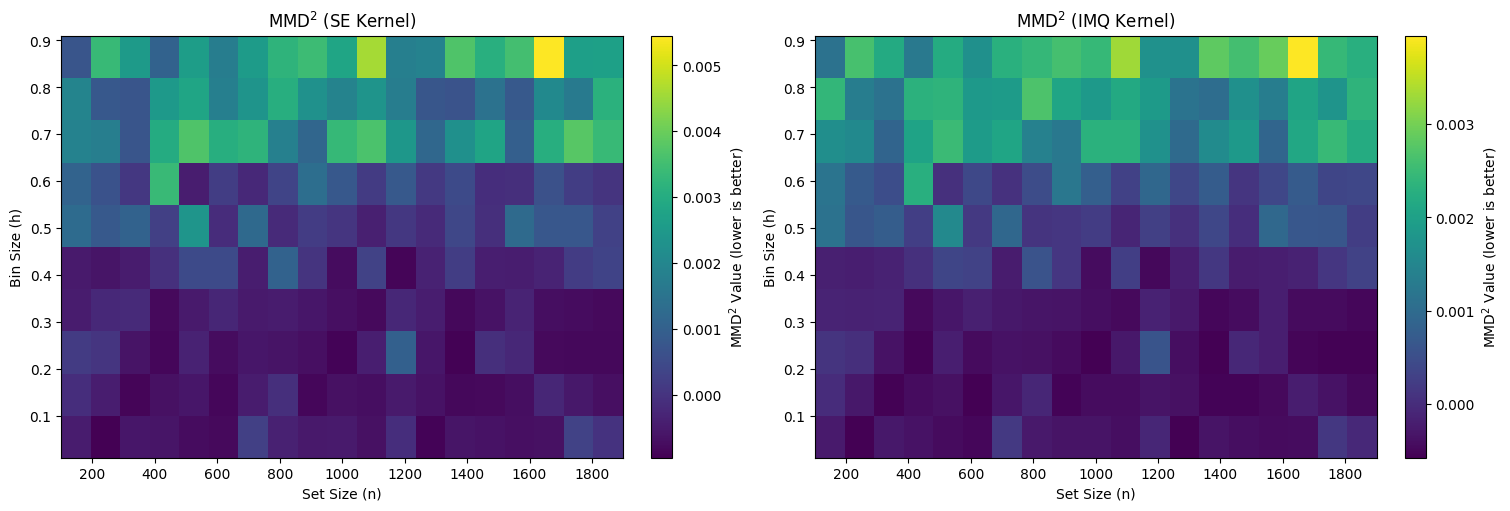

In [14]:
bin_sizes = np.arange(0.01, 1.01, 0.1)
set_sizes = np.arange(100, 2000, 100)

mat_se = np.zeros((len(bin_sizes), len(set_sizes)))
mat_imq = np.zeros((len(bin_sizes), len(set_sizes)))

for i, b in enumerate(bin_sizes):
    for j, n in enumerate(set_sizes):
        # Dataset.
        X, _ = make_moons(n_samples=n, noise=0.1)
        X_test, _ = make_moons(n_samples=1000, noise=0.1)
        # Fit histogram model.
        model = Histogram2DModel(h=b).fit(X)

        # Sample from the model.
        samples = model.sample(1000)

        # Compute MMD^2.
        mmd2_se = mmd_2(X_test, samples, h=1.0, k=se)
        mat_se[i, j] = mmd2_se
        mmd2_imq = mmd_2(X_test, samples, h=1.0, k=imq)
        mat_imq[i, j] = mmd2_imq

# Plot heatmaps.
fig, axes = plt.subplots(
    1, 2, 
    figsize=(15, 5), 
    constrained_layout=True
)

# MMD^2 with SE kernel.
im1 = axes[0].imshow(
    mat_se, 
    origin='lower', 
    aspect='auto', 
    extent=[
        set_sizes[0], set_sizes[-1], 
        bin_sizes[0], bin_sizes[-1]
    ],
    cmap='viridis'
)
axes[0].set_title("MMD$^2$ (SE Kernel)")
axes[0].set_xlabel("Set Size (n)")
axes[0].set_ylabel("Bin Size (h)")
fig.colorbar(im1, ax=axes[0], label="MMD$^2$ Value (lower is better)")

# MMD^2 with IMQ kernel.
im2 = axes[1].imshow(
    mat_imq, 
    origin='lower',
    aspect='auto',
    extent=[
        set_sizes[0], set_sizes[-1], 
        bin_sizes[0], bin_sizes[-1]
    ],
    cmap='viridis'
)
axes[1].set_title("MMD$^2$ (IMQ Kernel)")
axes[1].set_xlabel("Set Size (n)")
axes[1].set_ylabel("Bin Size (h)")
fig.colorbar(im2, ax=axes[1], label="MMD$^2$ Value (lower is better)")

plt.show()

For bigger training sets, the
accuracy decreases with increasing bin size, which can be explained by the
uniform sampling inside each bin. With bigger sampling area, the chance to
introduce noice increases and small h -> many bins. This also explains, why the
accuracy is somewhat independent of n.

---
#### Single Gaussian

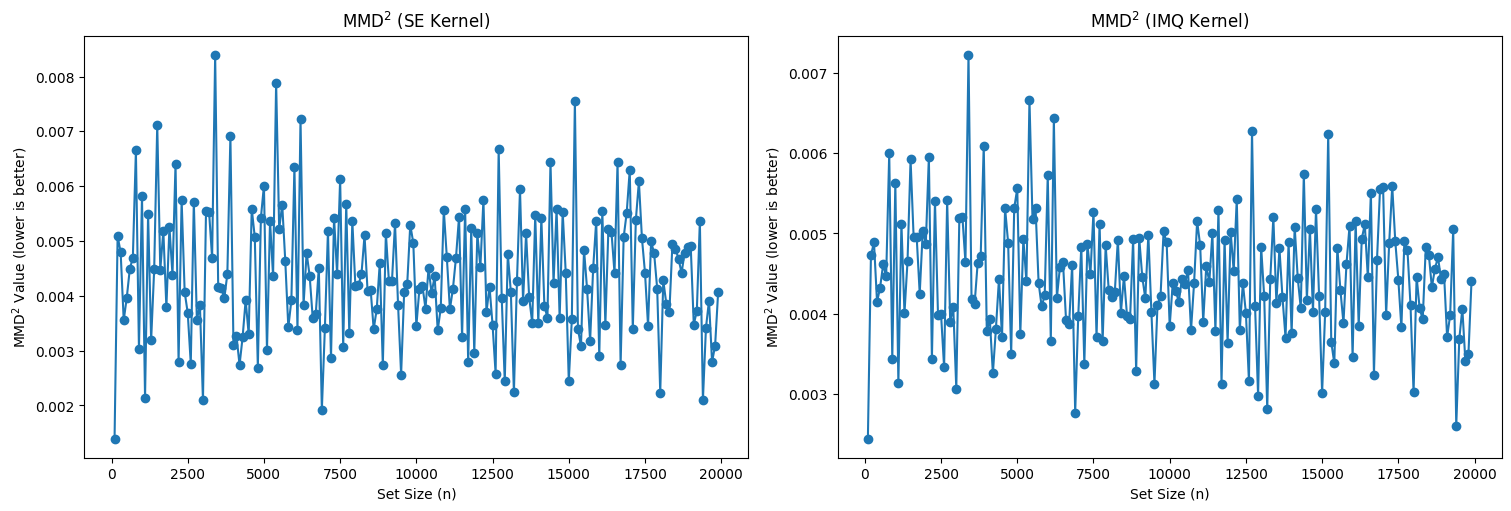

In [15]:
set_sizes = np.arange(100, 20000, 100)

points_se = np.zeros(len(set_sizes))
points_imq = np.zeros(len(set_sizes))

for j, n in enumerate(set_sizes):
    # Dataset.
    X, _ = make_moons(n_samples=n, noise=0.1)
    X_test, _ = make_moons(n_samples=1000, noise=0.1)
    
    # Fit model.
    model = SingleGaussianModel().fit(X)

    # Sample from the model.
    samples = model.sample(1000)

    # Compute MMD^2.
    mmd2_se = mmd_2(X_test, samples, h=1.0, k=se)
    points_se[j] = mmd2_se
    mmd2_imq = mmd_2(X_test, samples, h=1.0, k=imq)
    points_imq[j] = mmd2_imq

# Plot heatmaps.
fig, axes = plt.subplots(
    1, 2, 
    figsize=(15, 5), 
    constrained_layout=True
)

# MMD^2 with SE kernel.
axes[0].plot(set_sizes, points_se, marker='o', linestyle='-')
axes[0].set_title("MMD$^2$ (SE Kernel)")
axes[0].set_xlabel("Set Size (n)")
axes[0].set_ylabel("MMD$^2$ Value (lower is better)")

# MMD^2 with IMQ kernel.
axes[1].plot(set_sizes, points_imq, marker='o', linestyle='-')
axes[1].set_title("MMD$^2$ (IMQ Kernel)")
axes[1].set_xlabel("Set Size (n)")
axes[1].set_ylabel("MMD$^2$ Value (lower is better)")

plt.show()

The fit is doesn't increase with increasing n, but the overall fit is ok since
the model fits all the data into a single blob.

---
#### GMM

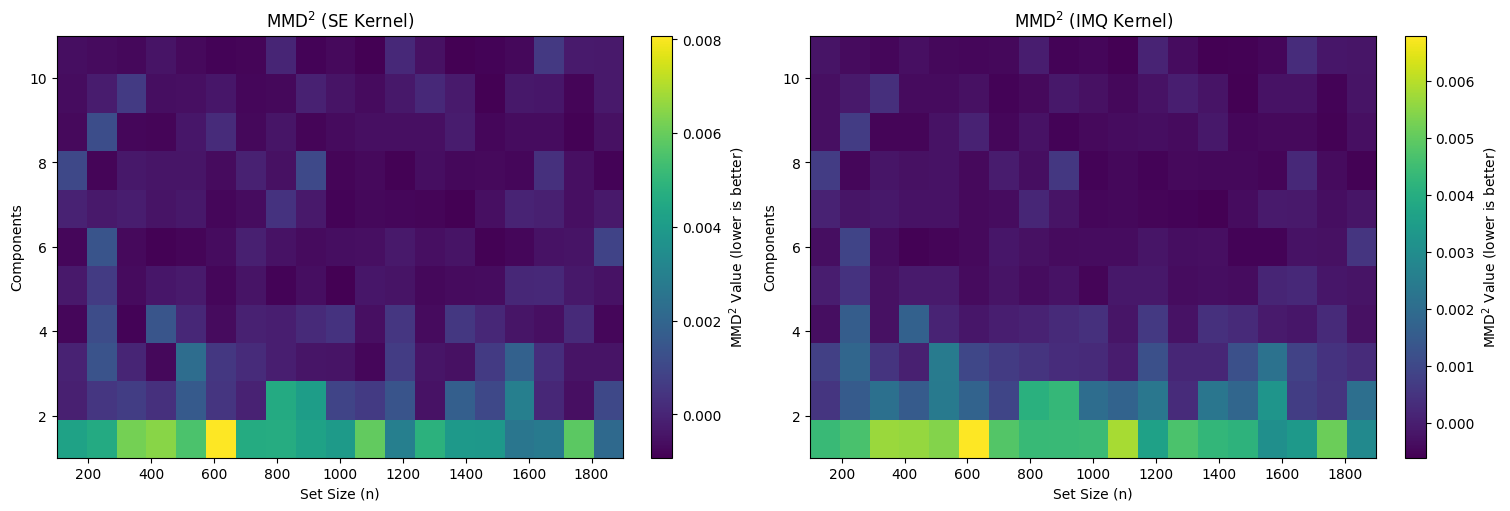

In [16]:
components = np.arange(1, 12, 1)
set_sizes = np.arange(100, 2000, 100)

mat_se = np.zeros((len(components), len(set_sizes)))
mat_imq = np.zeros((len(components), len(set_sizes)))

for i, c in enumerate(components):
    for j, n in enumerate(set_sizes):
        # Dataset.
        X, _ = make_moons(n_samples=n, noise=0.1)
        X_test, _ = make_moons(n_samples=1000, noise=0.1)

        # Fit model.
        model = GMM(n_components=c).fit(X)

        # Sample from the model.
        samples = model.sample(1000)

        # Compute MMD^2.
        mmd2_se = mmd_2(X_test, samples, h=1.0, k=se)
        mat_se[i, j] = mmd2_se
        mmd2_imq = mmd_2(X_test, samples, h=1.0, k=imq)
        mat_imq[i, j] = mmd2_imq

# Plot heatmaps.
fig, axes = plt.subplots(
    1, 2, 
    figsize=(15, 5), 
    constrained_layout=True
)

# MMD^2 with SE kernel.
im1 = axes[0].imshow(
    mat_se, 
    origin='lower', 
    aspect='auto', 
    extent=[
        set_sizes[0], set_sizes[-1], 
        components[0], components[-1]
    ],
    cmap='viridis'
)
axes[0].set_title("MMD$^2$ (SE Kernel)")
axes[0].set_xlabel("Set Size (n)")
axes[0].set_ylabel("Components")
fig.colorbar(im1, ax=axes[0], label="MMD$^2$ Value (lower is better)")

# MMD^2 with IMQ kernel.
im2 = axes[1].imshow(
    mat_imq, 
    origin='lower',
    aspect='auto',
    extent=[
        set_sizes[0], set_sizes[-1], 
        components[0], components[-1]
    ],
    cmap='viridis'
)
axes[1].set_title("MMD$^2$ (IMQ Kernel)")
axes[1].set_xlabel("Set Size (n)")
axes[1].set_ylabel("Components")
fig.colorbar(im2, ax=axes[1], label="MMD$^2$ Value (lower is better)")

plt.show()

As expected, the accuracy of this model increases with the number of components
and ignores TS size,
as the model can be fitted even more precisely to the data.

---
#### KDE

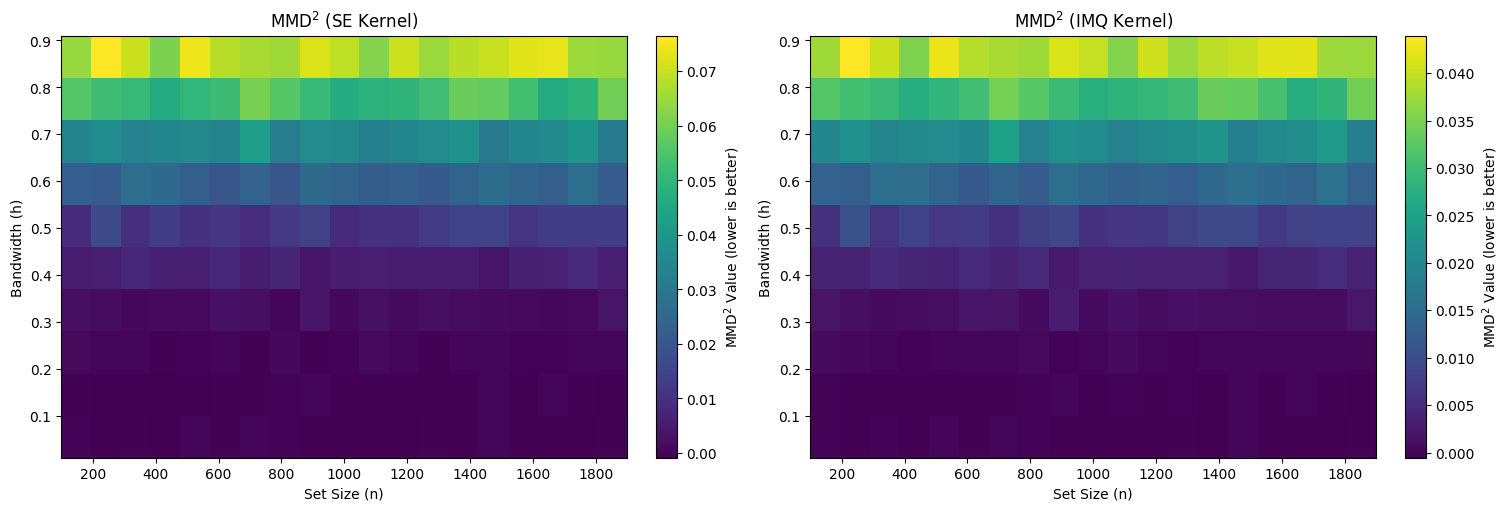

In [17]:
bandwidths = np.arange(0.01, 1.01, 0.1)
set_sizes = np.arange(100, 2000, 100)

mat_se = np.zeros((len(bandwidths), len(set_sizes)))
mat_imq = np.zeros((len(bandwidths), len(set_sizes)))

for i, b in enumerate(bandwidths):
    for j, n in enumerate(set_sizes):
        # Dataset.
        X, _ = make_moons(n_samples=n, noise=0.1)
        X_test, _ = make_moons(n_samples=1000, noise=0.1)

        # Fit model.
        model = KDEGaussian(h=b).fit(X)

        # Sample from the model.
        samples = model.sample(1000)

        # Compute MMD^2.
        mmd2_se = mmd_2(X_test, samples, h=1.0, k=se)
        mat_se[i, j] = mmd2_se
        mmd2_imq = mmd_2(X_test, samples, h=1.0, k=imq)
        mat_imq[i, j] = mmd2_imq

# Plot heatmaps.
fig, axes = plt.subplots(
    1, 2, 
    figsize=(15, 5), 
    constrained_layout=True
)

# MMD^2 with SE kernel.
im1 = axes[0].imshow(
    mat_se, 
    origin='lower', 
    aspect='auto', 
    extent=[
        set_sizes[0], set_sizes[-1], 
        bandwidths[0], bandwidths[-1]
    ],
    cmap='viridis'
)
axes[0].set_title("MMD$^2$ (SE Kernel)")
axes[0].set_xlabel("Set Size (n)")
axes[0].set_ylabel("Bandwidth (h)")
fig.colorbar(im1, ax=axes[0], label="MMD$^2$ Value (lower is better)")

# MMD^2 with IMQ kernel.
im2 = axes[1].imshow(
    mat_imq, 
    origin='lower',
    aspect='auto',
    extent=[
        set_sizes[0], set_sizes[-1], 
        bandwidths[0], bandwidths[-1]
    ],
    cmap='viridis'
)
axes[1].set_title("MMD$^2$ (IMQ Kernel)")
axes[1].set_xlabel("Set Size (n)")
axes[1].set_ylabel("Bandwidth (h)")
fig.colorbar(im2, ax=axes[1], label="MMD$^2$ Value (lower is better)")

plt.show()

Smaller bandwidth -> smaller sigma for the pointwise gaussian distributions ->
less noise in sampling. While this produces smaller MMD^2, this would also cause
more overfitting, which whould also be bad if the moon noise increased!

---
### Representatives
---

In [18]:
def plot_rep(model, X_train, n_samples=2000, grid_res=250):
    
    model = model.fit(X_train)
    
    samples = model.sample(n_samples)

    all_data = np.concatenate((X_train, samples), axis=0)

    # Create grid.
    x_min, x_max = np.min(all_data[:,0]), np.max(all_data[:,0])
    y_min, y_max = np.min(all_data[:,1]), np.max(all_data[:,1])

    xs = np.linspace(x_min, x_max, grid_res)
    ys = np.linspace(y_min, y_max, grid_res)
    X, Y = np.meshgrid(xs, ys)

    fig, axes = plt.subplots(
        1, 2, 
        figsize=(15, 4.5), 
        constrained_layout=True, 
        sharex=True, 
        sharey=True
    )
    # Density plot.
    points = np.column_stack([X.ravel(), Y.ravel()])
    scores = model.score_samples(points)
    scores = np.asarray(scores).reshape(X.shape)

    # Covert log-density -> density for visualization.
    scores = np.exp(scores)

    cf = axes[0].contourf(X, Y, scores, levels=30)
    axes[0].set_title("Density from score_samples")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    cbar = fig.colorbar(cf, ax=axes[0])
    cbar.set_label("Density")

    # Sample plot.
    axes[1].scatter(samples[:,0], samples[:,1], s=10, alpha=0.5)
    axes[1].set_title(f"Generated samples (n={n_samples})")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")

    # Ensure equal aspect ratio.
    for ax in axes.flatten():
        ax.set_xlim(*[x_min, x_max])
        ax.set_ylim(*[y_min, y_max])
        ax.set_aspect('equal', adjustable='box')

    plt.show()

train_set, _ = make_moons(n_samples=3000, noise=0.1)

#### Bad

##### Histogram with large bin size:

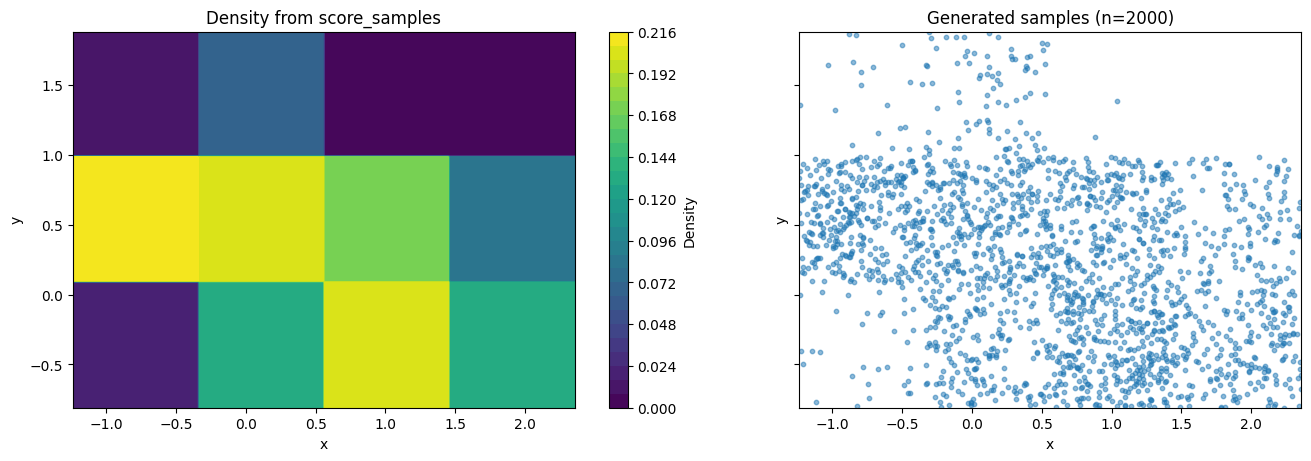

In [19]:
model = Histogram2DModel(h=0.9)
plot_rep(model, train_set)

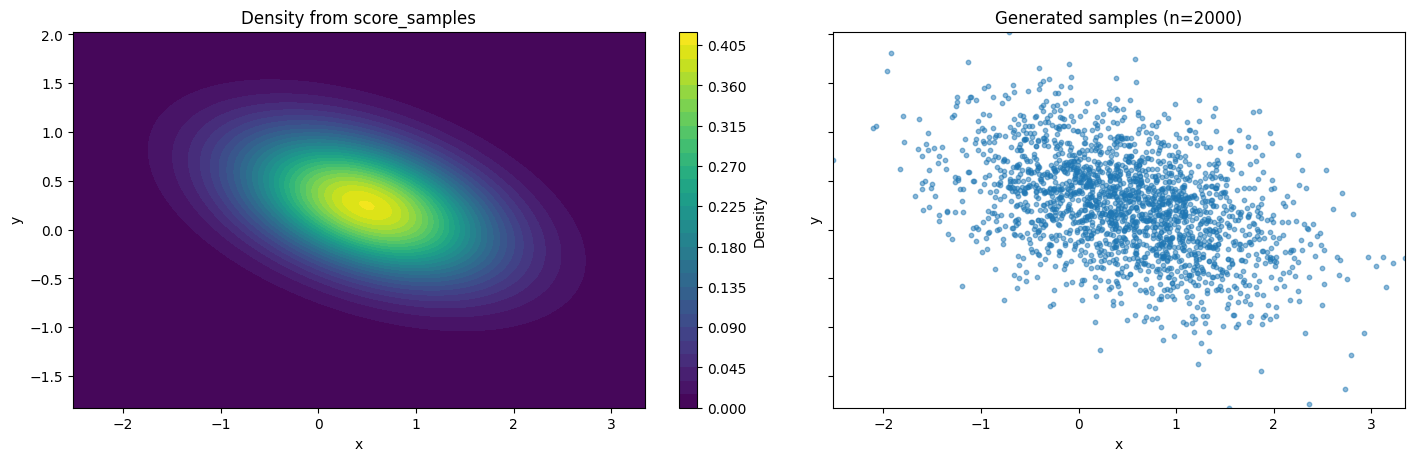

In [20]:
model = SingleGaussianModel()
plot_rep(model, train_set)

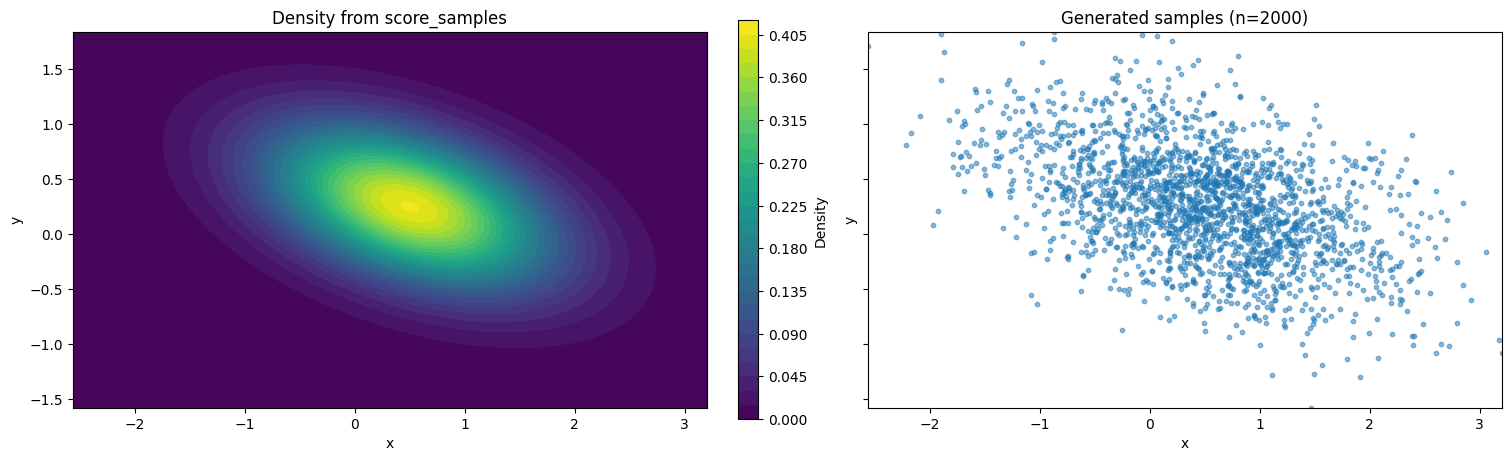

In [21]:
model = GMM(n_components=1)
plot_rep(model, train_set)

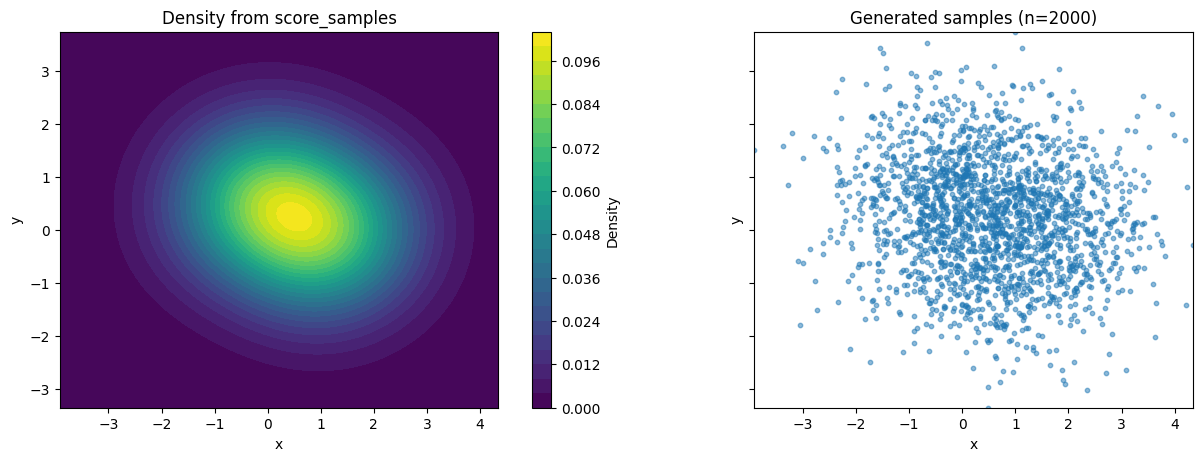

In [22]:
model = KDEGaussian(h=1)
plot_rep(model, train_set)

#### Good

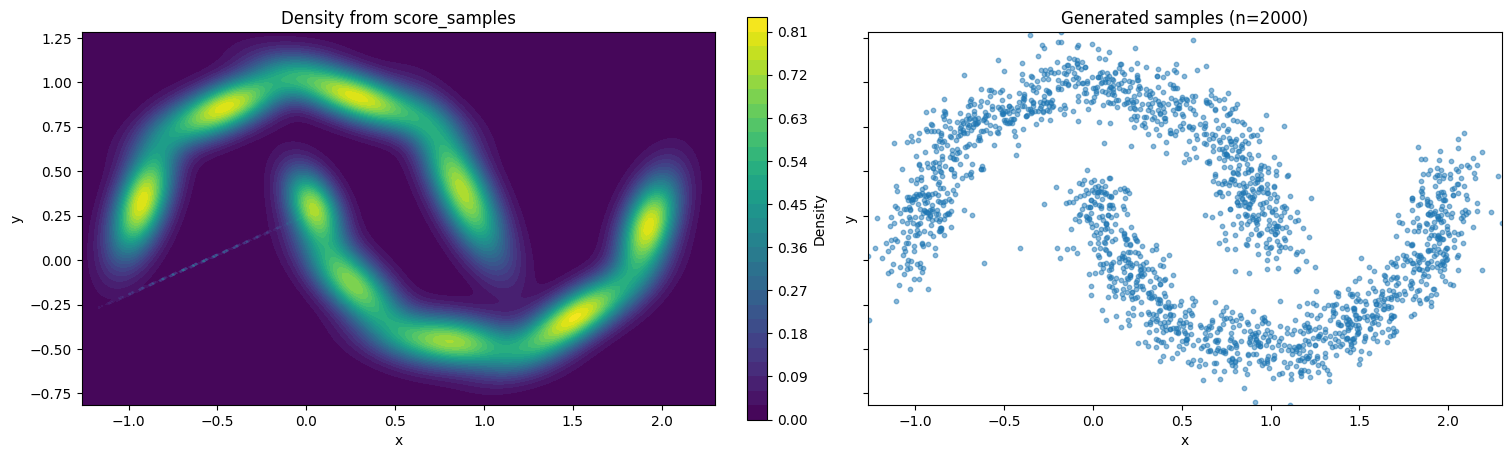

In [23]:
model = GMM(n_components=10)
plot_rep(model, train_set)

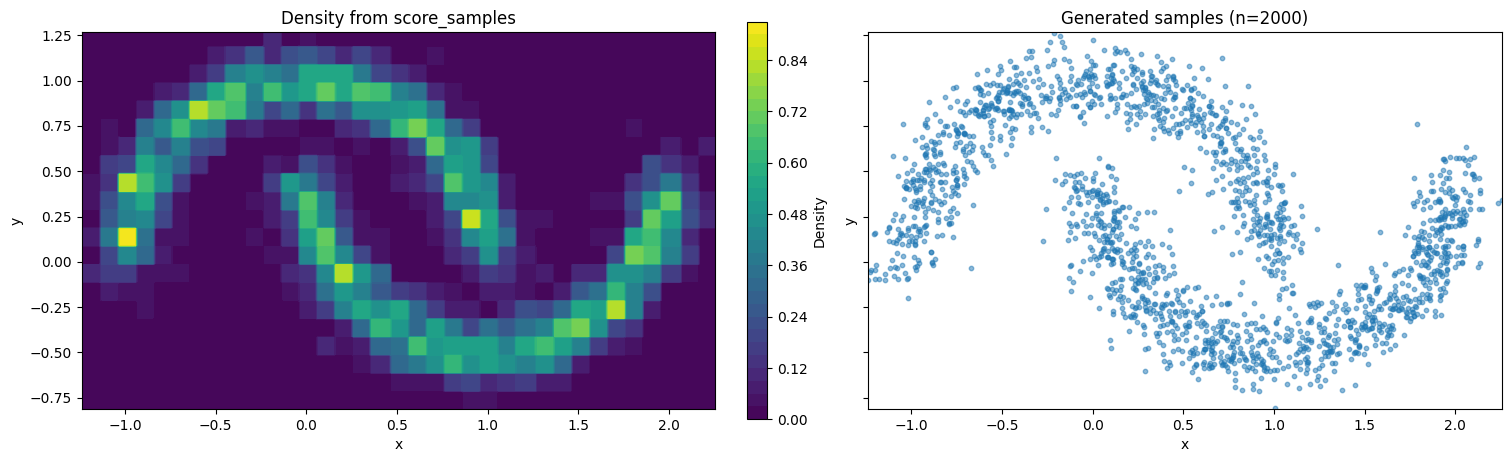

In [24]:
model = Histogram2DModel(h=0.1)
plot_rep(model, train_set)

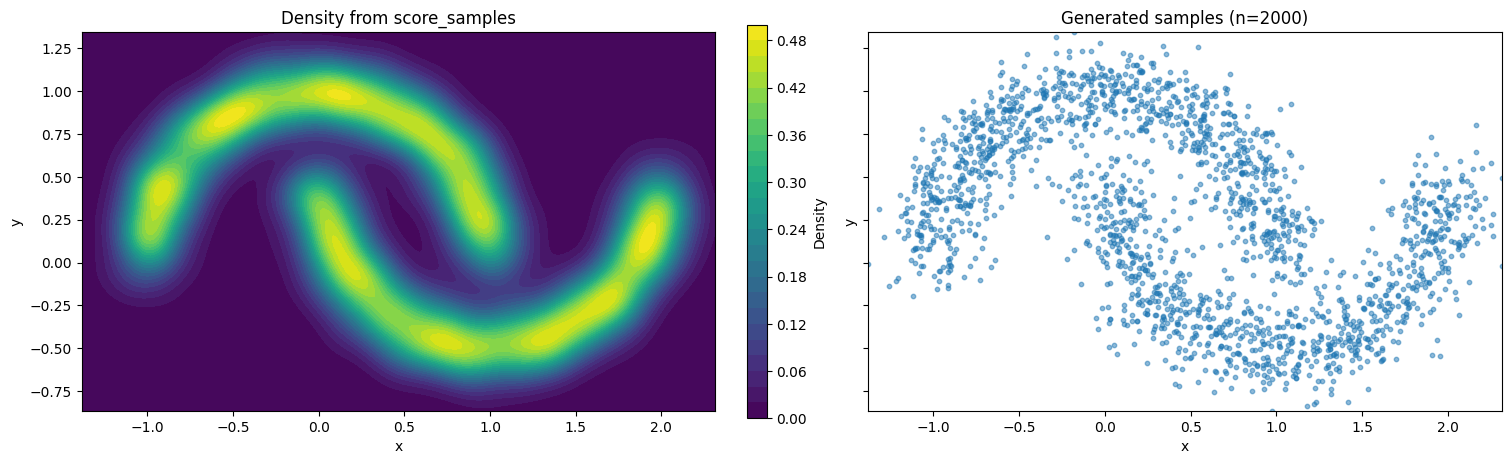

In [25]:
model = KDEGaussian(h=0.1)
plot_rep(model, train_set)

##### Overfitted

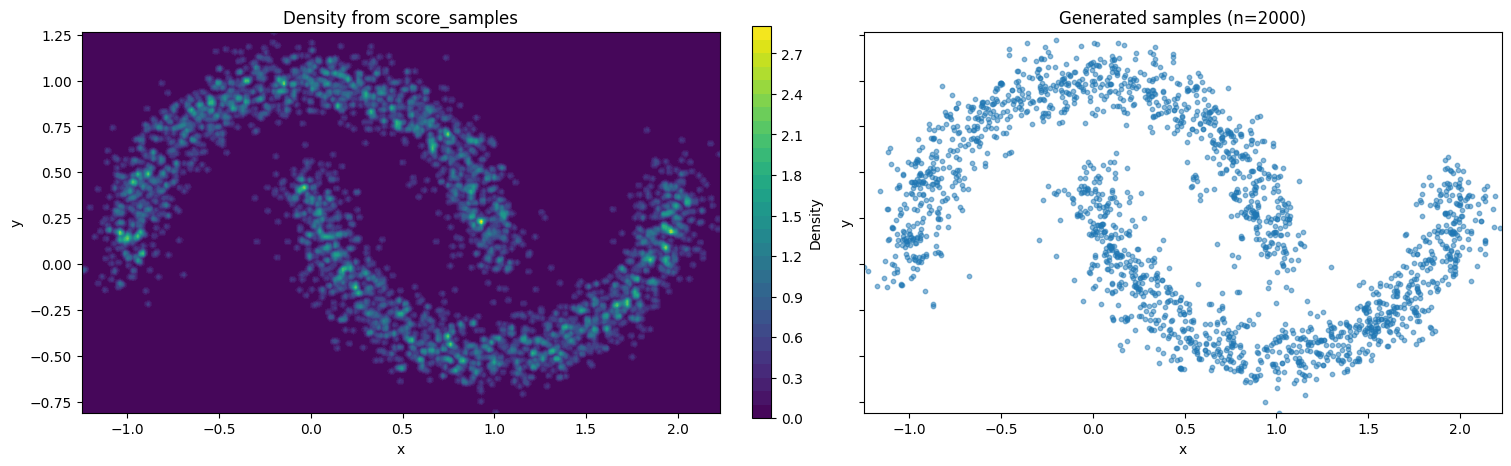

In [26]:
model = KDEGaussian(h=0.01)
plot_rep(model, train_set)

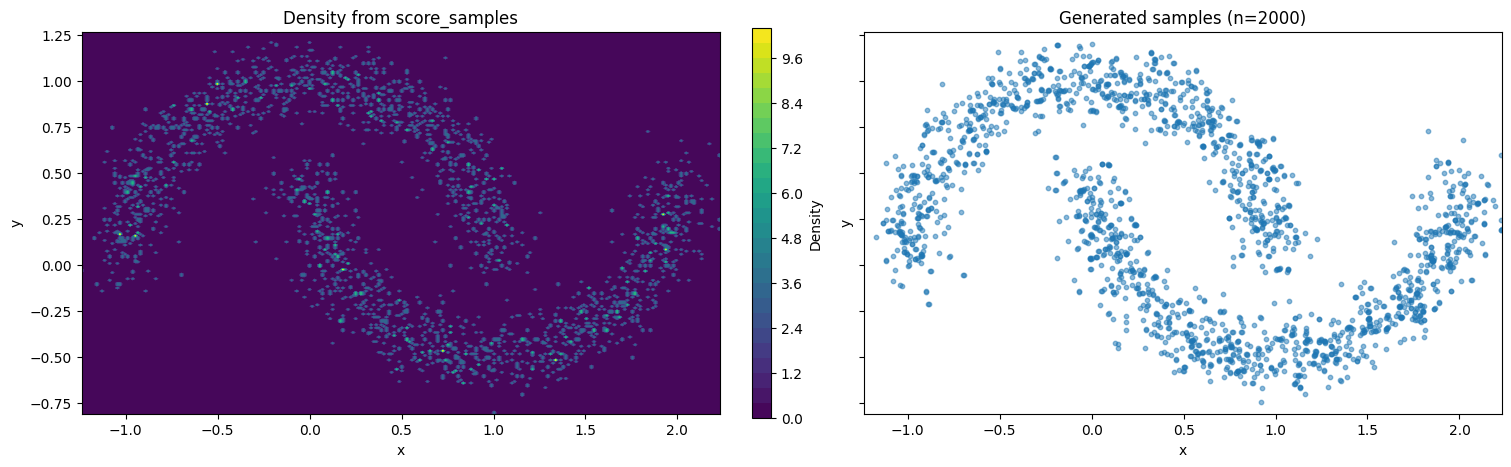

In [27]:
model = Histogram2DModel(h=0.01)
plot_rep(model, train_set)

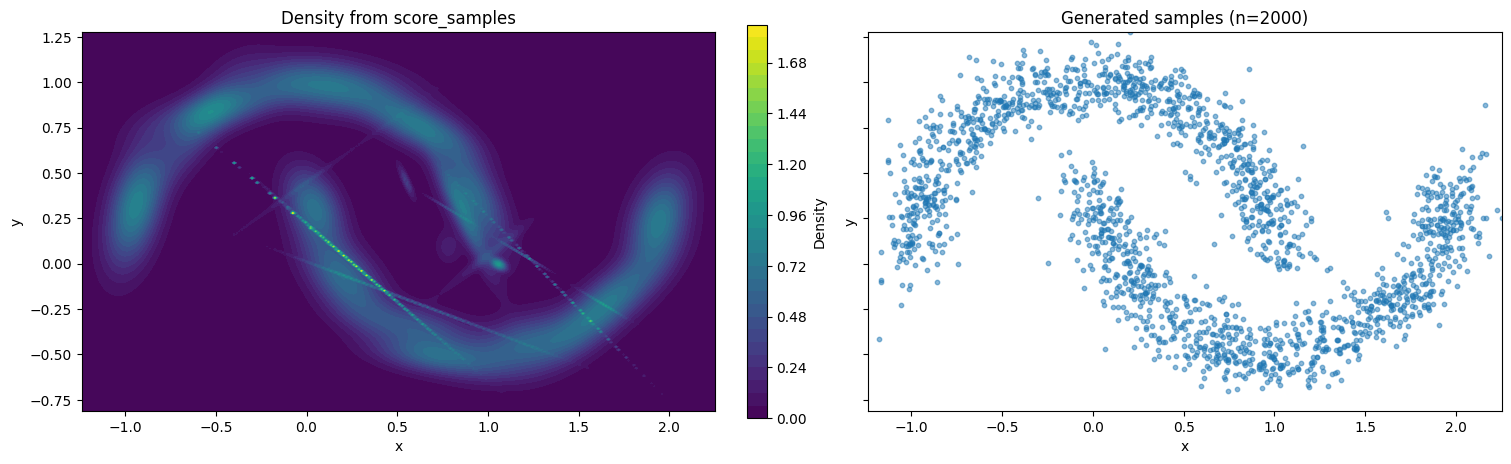

In [28]:
model = GMM(n_components=25)
plot_rep(model, train_set)

---
#### Pro vs Con
---

##### Histogram
Pro
- Easy to implement / fit
- Relative good fit with a reasonable bin size

Con
- Large bin size -> Very bad fit
- Small bin size -> Overfitting
- Hard to balance
- Does not scale well
---
##### SingleGaussian
Pro
- Easy and fast
- No hyperparameter

Con
- Very Bad Fit
- Groups data into single blob
---
##### GMM
Pro
- Good fit with a few components

Con
- Computationally expensive
- Possible overfitting
- Very few components -> not much better than Single
---
##### KDE
Pro
- Possibly even better fit than GMM
- Faster than GMM with a few components

Con
- Large bandwith -> Fits data into single blob
- Small bandwith -> Overfitting
- Hard to balance

---
## Task 2
---

<div style="color: green; font-weight: bold">

Data set import and separation in test and training set is equivalent to the solution.

Several models are trained with better and worse hyperparameters (pretty much equivalent to solution):
- Density forest with the provided class 
- GMM, 10 components
- GMM, 1 component
- KDE, bandwidth 1.0
- KDE, bandwidth 100

The hyperparameters shown...
- are relatively low for the number of components in the GMMs (higher number of components would mean better fit, if not overfitted) 
- are comparably high values for the KDE bandwidth (lower bandwidth would mean better fit/higher resolution, if not overfitted). 

Generated samples are specifically shown in the Representatives section and the overall trends for better or worse hyperparameters are clearly presented. 

MMD^2 evaluation: 

The calculated values are first printed for the different values and then their dependence on h and test set size n is shown in plots.
    
The resolution in terms of test set size n is very high (step size = 10), while the bandwidth h for the MMD^2 calculation is also relatively high (ca. 0.25 - 2.0). 
Hence, the calculation is pretty costly, while the heat maps mainly tend to show the less-sensible range of the MMD^2 due to oversmoothing of the differences. 

- This would maybe have been more effective, if fewer n values and a smaller range of h values (e.g. 0.1 - 1.0) were chosen.

- This intensive plotting was probably also one of the reasons, why the DensityForest MMD^2 evaluation took too much time to run.

RandomForestClassifier:

Rf is fitted as in the solution, but its score with the test set is not reported.

It is used later on to predict the labels of the generated samples (also shown in the plots of generated samples). 

The distribution of predicted labels is not plotted, but printed and can be compared that way (equiv. to solution).

</div>

---
### Imports
---

In [29]:
from sklearn.datasets import load_digits
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity
from sklearn.ensemble import RandomForestClassifier
from density_forest import DensityForest
from sklearn.model_selection import train_test_split

ModuleNotFoundError: No module named 'density_forest'

---
### Data
---

In [ ]:
digits = load_digits()
X_full = digits.data.astype(float) # (n_samples, 64)
y_full = digits.target.astype(int) # 0..9

# Training and Test data.
X_train, X_test, y_train, y_test = train_test_split(
    X_full, 
    y_full, 
    test_size=0.25, 
    stratify=y_full
)

print(X_train.shape, X_test.shape)

(1347, 64) (450, 64)


---
### RF Classifier
---

In [ ]:
classifier = RandomForestClassifier()
classifier.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


---
### Models
---

In [ ]:
df_model = DensityForest()
df_model.fit(X_train)

gmm_model = GaussianMixture(n_components=10)
gmm_model.fit(X_train)

single_model = GaussianMixture(n_components=1)
single_model.fit(X_train)

kde_model_1 = KernelDensity(bandwidth=100.0)
kde_model_1.fit(X_train)

kde_model_2 = KernelDensity(bandwidth=1)
kde_model_2.fit(X_train)

models = {
    "Density Forest": df_model,
    "GMM (10 components)": gmm_model,
    "Single Gaussian": single_model,
    "KDE (h=0.01)": kde_model_2
}

---
### $MMD^2$
---

---
#### Different h:
---

In [ ]:
# Possible bandwidths.
for b in [0.5, 1, 5, 12]:
    print(f"Bandwidth h = {b}\n")
    for name, model in models.items():
        samples = model.sample(X_test.shape[0])
        if isinstance(samples, tuple):
            samples = samples[0]
        mmd2_se = mmd_2(X_test, samples, h=b, k=se)
        mmd2_imq = mmd_2(X_test, samples, h=b, k=imq)
        print(
            f"Model: {name}, "
            f"MMD^2 (SE) = {mmd2_se:.6f}, MMD^2 (IMQ) = {mmd2_imq:.6f}"
        )
    print(f"\n---\n")

Bandwidth h = 0.5

Model: Density Forest, MMD^2 (SE) = 0.000269, MMD^2 (IMQ) = 0.000331
Model: GMM (10 components), MMD^2 (SE) = -0.000000, MMD^2 (IMQ) = 0.000033
Model: Single Gaussian, MMD^2 (SE) = 0.000000, MMD^2 (IMQ) = 0.000119
Model: KDE (h=0.01), MMD^2 (SE) = -0.000000, MMD^2 (IMQ) = 0.000031

---

Bandwidth h = 1

Model: Density Forest, MMD^2 (SE) = 0.000206, MMD^2 (IMQ) = 0.000235
Model: GMM (10 components), MMD^2 (SE) = -0.000000, MMD^2 (IMQ) = 0.000047
Model: Single Gaussian, MMD^2 (SE) = -0.000000, MMD^2 (IMQ) = 0.000220
Model: KDE (h=0.01), MMD^2 (SE) = -0.000000, MMD^2 (IMQ) = 0.000069

---

Bandwidth h = 5

Model: Density Forest, MMD^2 (SE) = 0.000333, MMD^2 (IMQ) = 0.000308
Model: GMM (10 components), MMD^2 (SE) = 0.000024, MMD^2 (IMQ) = 0.000311
Model: Single Gaussian, MMD^2 (SE) = 0.000025, MMD^2 (IMQ) = 0.001071
Model: KDE (h=0.01), MMD^2 (SE) = 0.000085, MMD^2 (IMQ) = 0.000171

---

Bandwidth h = 12

Model: Density Forest, MMD^2 (SE) = 0.000646, MMD^2 (IMQ) = 0.0005

---
#### DensityForest

This does not run fast enough on our systems, so we skiped this, but the code
should work :)

In [ ]:
# set_sizes = np.arange(100, X_train.shape[0], 10)

# points_se = np.zeros(len(set_sizes))
# points_imq = np.zeros(len(set_sizes))

# for j, n in enumerate(set_sizes):
#     # Fit model.
#     model = DensityForest()
#     model.fit(X_train[:n])

#     # Sample from the model.
#     samples = model.sample(X_test.shape[0])

#     # Compute MMD^2.
#     mmd2_se = mmd_2(X_test, samples, h=1.0, k=se)
#     points_se[j] = mmd2_se
#     mmd2_imq = mmd_2(X_test, samples, h=1.0, k=imq)
#     points_imq[j] = mmd2_imq

# # Plot heatmaps.
# fig, axes = plt.subplots(
#     1, 2, 
#     figsize=(15, 5), 
#     constrained_layout=True
# )

# # MMD^2 with SE kernel.
# axes[0].plot(set_sizes, points_se, marker='o', linestyle='-')
# axes[0].set_title("MMD$^2$ (SE Kernel)")
# axes[0].set_xlabel("Set Size (n)")
# axes[0].set_ylabel("MMD$^2$ Value (lower is better)")

# # MMD^2 with IMQ kernel.
# axes[1].plot(set_sizes, points_imq, marker='o', linestyle='-')
# axes[1].set_title("MMD$^2$ (IMQ Kernel)")
# axes[1].set_xlabel("Set Size (n)")
# axes[1].set_ylabel("MMD$^2$ Value (lower is better)")

# plt.show()

---
#### GMM

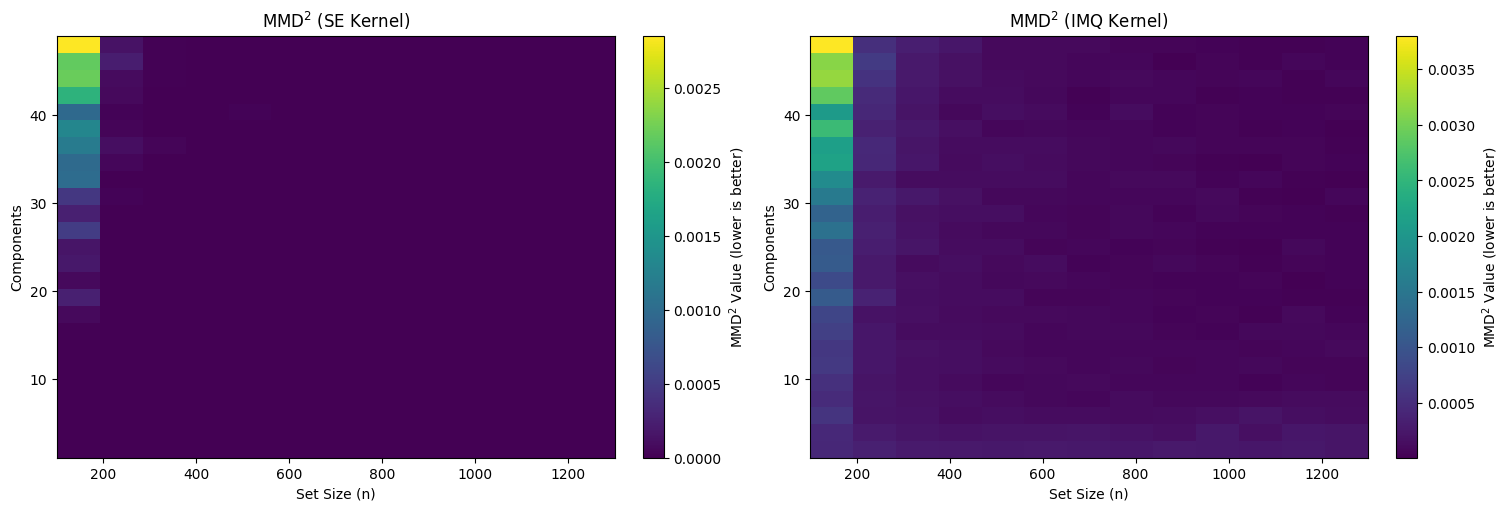

In [ ]:
components = np.arange(1, 50, 2)
set_sizes = np.arange(100, X_train.shape[0], 100)

mat_se = np.zeros((len(components), len(set_sizes)))
mat_imq = np.zeros((len(components), len(set_sizes)))

for i, c in enumerate(components):
    for j, n in enumerate(set_sizes):
        # Fit model.
        model = GaussianMixture(n_components=c).fit(X_train[:n])

        # Sample from the model.
        samples, _ = model.sample(X_test.shape[0])

        # Compute MMD^2.
        mmd2_se = mmd_2(X_test, samples, h=1.0, k=se)
        mat_se[i, j] = mmd2_se
        mmd2_imq = mmd_2(X_test, samples, h=1.0, k=imq)
        mat_imq[i, j] = mmd2_imq

# Plot heatmaps.
fig, axes = plt.subplots(
    1, 2, 
    figsize=(15, 5), 
    constrained_layout=True
)

# MMD^2 with SE kernel.
im1 = axes[0].imshow(
    mat_se, 
    origin='lower', 
    aspect='auto', 
    extent=[
        set_sizes[0], set_sizes[-1], 
        components[0], components[-1]
    ],
    cmap='viridis'
)
axes[0].set_title("MMD$^2$ (SE Kernel)")
axes[0].set_xlabel("Set Size (n)")
axes[0].set_ylabel("Components")
fig.colorbar(im1, ax=axes[0], label="MMD$^2$ Value (lower is better)")

# MMD^2 with IMQ kernel.
im2 = axes[1].imshow(
    mat_imq, 
    origin='lower',
    aspect='auto',
    extent=[
        set_sizes[0], set_sizes[-1], 
        components[0], components[-1]
    ],
    cmap='viridis'
)
axes[1].set_title("MMD$^2$ (IMQ Kernel)")
axes[1].set_xlabel("Set Size (n)")
axes[1].set_ylabel("Components")
fig.colorbar(im2, ax=axes[1], label="MMD$^2$ Value (lower is better)")

plt.show()

For small n, less components = better fit. But with a reasonable n, the model
has a well fit, mostly independent of the component number.

---
#### SingleGaussian

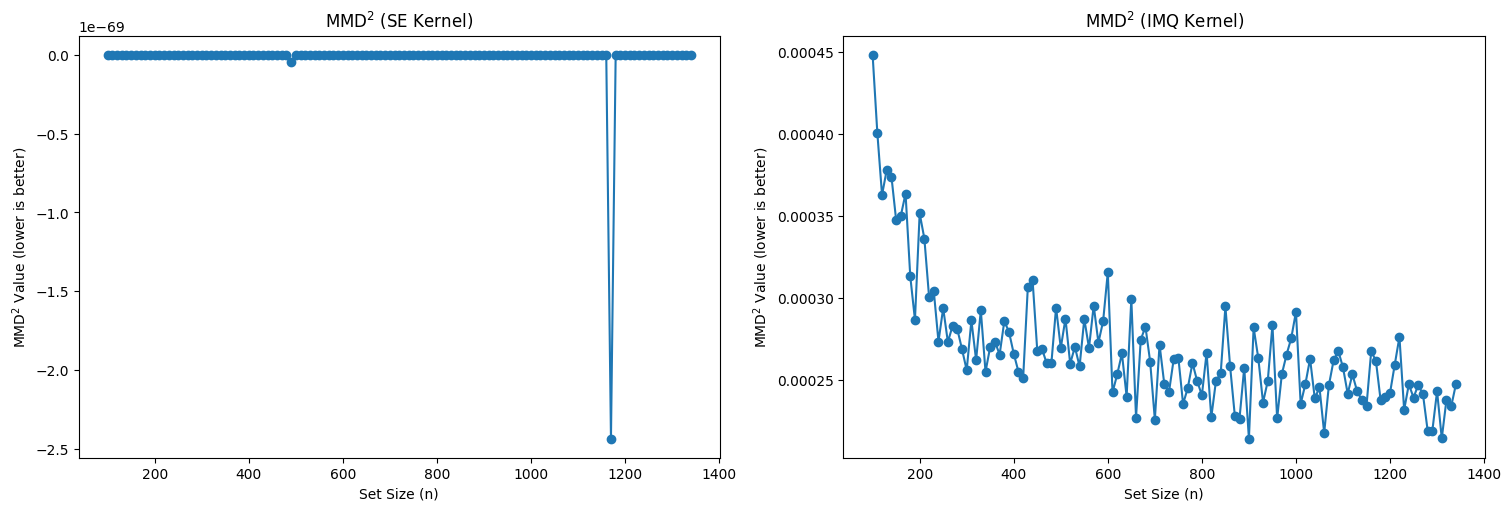

In [ ]:
set_sizes = np.arange(100, X_train.shape[0], 10)

points_se = np.zeros(len(set_sizes))
points_imq = np.zeros(len(set_sizes))

for j, n in enumerate(set_sizes):
    # Fit model.
    model = GaussianMixture(n_components=1).fit(X_train[:n])

    # Sample from the model.
    samples, _ = model.sample(X_test.shape[0])

    # Compute MMD^2.
    mmd2_se = mmd_2(X_test, samples, h=1.0, k=se)
    points_se[j] = mmd2_se
    mmd2_imq = mmd_2(X_test, samples, h=1.0, k=imq)
    points_imq[j] = mmd2_imq

# Plot heatmaps.
fig, axes = plt.subplots(
    1, 2, 
    figsize=(15, 5), 
    constrained_layout=True
)

# MMD^2 with SE kernel.
axes[0].plot(set_sizes, points_se, marker='o', linestyle='-')
axes[0].set_title("MMD$^2$ (SE Kernel)")
axes[0].set_xlabel("Set Size (n)")
axes[0].set_ylabel("MMD$^2$ Value (lower is better)")

# MMD^2 with IMQ kernel.
axes[1].plot(set_sizes, points_imq, marker='o', linestyle='-')
axes[1].set_title("MMD$^2$ (IMQ Kernel)")
axes[1].set_xlabel("Set Size (n)")
axes[1].set_ylabel("MMD$^2$ Value (lower is better)")

plt.show()

SE: Ok fit that does not change.

IMQ: Increasing n -> better fit. Higher Dim might be fitted into blob.

---
#### KDE

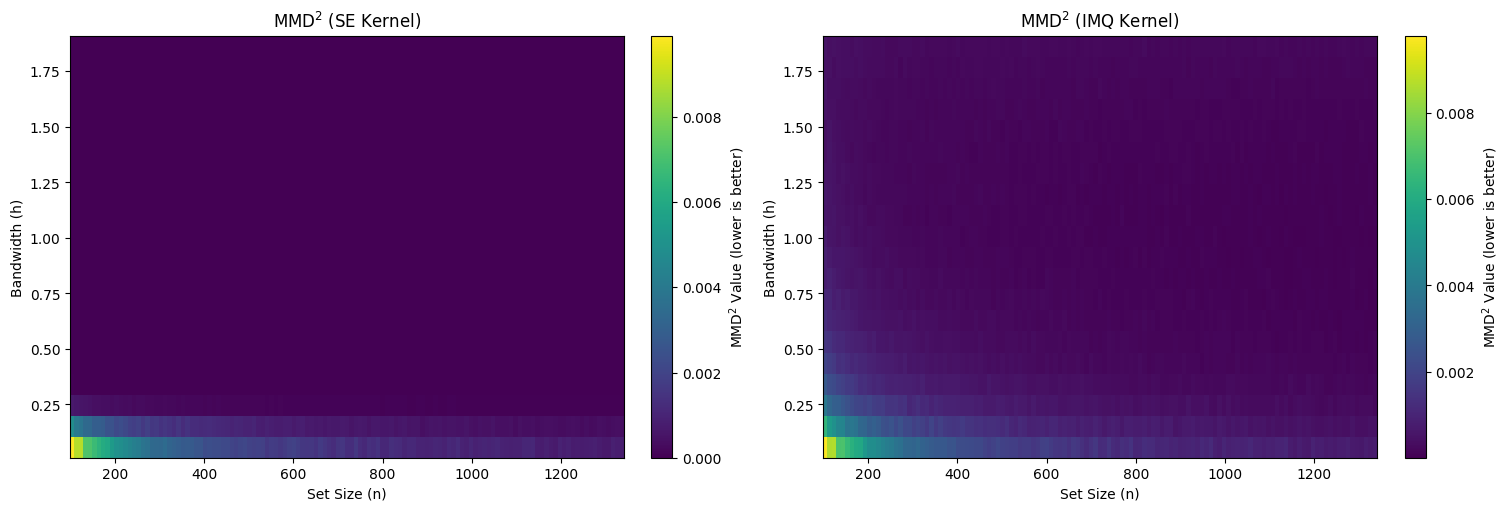

In [ ]:
bandwidths = np.arange(0.01, 2.01, 0.1)
set_sizes = np.arange(100, X_train.shape[0], 10)

mat_se = np.zeros((len(bandwidths), len(set_sizes)))
mat_imq = np.zeros((len(bandwidths), len(set_sizes)))

for i, b in enumerate(bandwidths):
    for j, n in enumerate(set_sizes):
        model = KernelDensity(bandwidth=b).fit(X_train[:n])

        # Sample from the model.
        samples = model.sample(X_test.shape[0])

        # Compute MMD^2.
        mmd2_se = mmd_2(X_test, samples, h=1.0, k=se)
        mat_se[i, j] = mmd2_se
        mmd2_imq = mmd_2(X_test, samples, h=1.0, k=imq)
        mat_imq[i, j] = mmd2_imq

# Plot heatmaps.
fig, axes = plt.subplots(
    1, 2, 
    figsize=(15, 5), 
    constrained_layout=True
)

# MMD^2 with SE kernel.
im1 = axes[0].imshow(
    mat_se, 
    origin='lower', 
    aspect='auto', 
    extent=[
        set_sizes[0], set_sizes[-1], 
        bandwidths[0], bandwidths[-1]
    ],
    cmap='viridis'
)
axes[0].set_title("MMD$^2$ (SE Kernel)")
axes[0].set_xlabel("Set Size (n)")
axes[0].set_ylabel("Bandwidth (h)")
fig.colorbar(im1, ax=axes[0], label="MMD$^2$ Value (lower is better)")

# MMD^2 with IMQ kernel.
im2 = axes[1].imshow(
    mat_imq, 
    origin='lower',
    aspect='auto',
    extent=[
        set_sizes[0], set_sizes[-1], 
        bandwidths[0], bandwidths[-1]
    ],
    cmap='viridis'
)
axes[1].set_title("MMD$^2$ (IMQ Kernel)")
axes[1].set_xlabel("Set Size (n)")
axes[1].set_ylabel("Bandwidth (h)")
fig.colorbar(im2, ax=axes[1], label="MMD$^2$ Value (lower is better)")

plt.show()

With larger Dimension, smaller bandwidths become worse, while the tolerance for
larger bandwidths increases. The problem with small bandwidths lessens with
increasing n.

---
### Representatives
---

In [ ]:
def show_image_grid(
        X, 
        n=40, 
        cols=10, 
        title=None, 
        predictions=None
):
    """
    Displays a grid of images.

    Parameters
    ----------
    X : array-like, shape (n_samples, 64)
        Input images.
    n : int, optional
        Number of images to display.
    cols : int, optional
        Number of columns.
    title : str, optional
        Title.
    predictions : array-like, shape (n_samples,), optional
        Predicted labels for the images.
    """

    n = min(n, len(X))
    rows = np.ceil(n / cols).astype(int)
    fig = plt.figure(figsize=(cols * 1.2, rows * 1.2))
    for i in range(n):
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(
            X[i].reshape(8, 8), 
            cmap='gray', 
            vmin=0, 
            vmax=16, 
            interpolation='nearest'
        )
        if predictions is not None:
            ax.set_title(f"Pred: {predictions[i]}", fontsize=8)
        ax.axis('off')
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

---
#### DensityForest
---

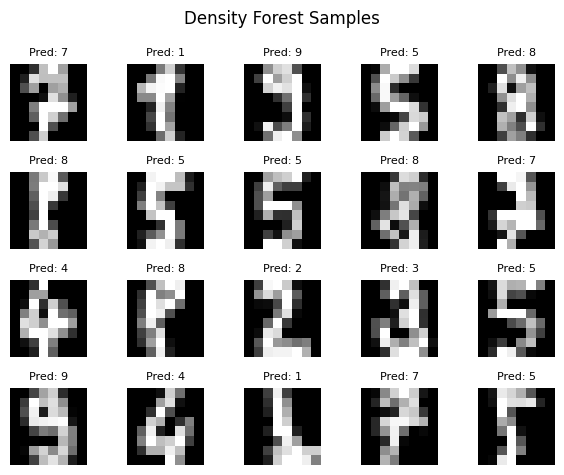

Digit 0: 97 samples
Digit 1: 103 samples
Digit 2: 107 samples
Digit 3: 126 samples
Digit 4: 97 samples
Digit 5: 91 samples
Digit 6: 101 samples
Digit 7: 74 samples
Digit 8: 100 samples
Digit 9: 104 samples


In [ ]:
n = 20

samples = df_model.sample(n)
predictions = classifier.predict(samples).astype(int)

show_image_grid(
    samples, 
    n=n, 
    cols=5, 
    title="Density Forest Samples",
    predictions=predictions
)

samples = df_model.sample(1000)
predictions = classifier.predict(samples).astype(int)
counts = np.bincount(predictions, minlength=10)
for digit in range(10):
    print(f"Digit {digit}: {counts[digit]} samples")

---
#### GMM
---

##### Good

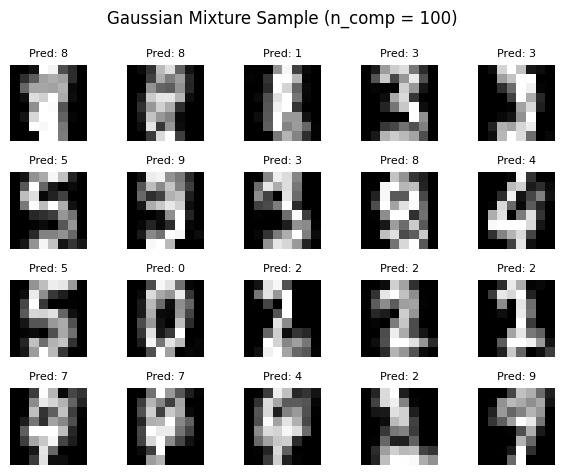

Digit 0: 101 samples
Digit 1: 86 samples
Digit 2: 106 samples
Digit 3: 84 samples
Digit 4: 100 samples
Digit 5: 103 samples
Digit 6: 113 samples
Digit 7: 89 samples
Digit 8: 92 samples
Digit 9: 126 samples


In [ ]:
n = 20

# Samples + labels.
samples, _ = gmm_model.sample(n)
predictions = classifier.predict(samples).astype(int)

show_image_grid(
    samples, 
    n=n, 
    cols=5, 
    title="Gaussian Mixture Sample (n_comp = 100)",
    predictions=predictions
)

samples, _ = gmm_model.sample(1000)
predictions = classifier.predict(samples).astype(int)
counts = np.bincount(predictions, minlength=10)
for digit in range(10):
    print(f"Digit {digit}: {counts[digit]} samples")

---
##### Bad (Single Gaussian)

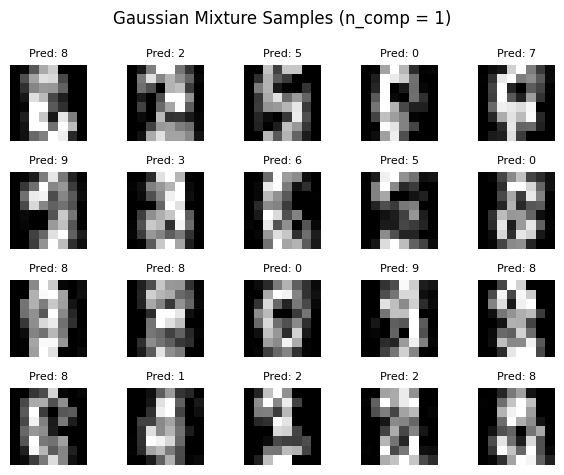

Digit 0: 76 samples
Digit 1: 33 samples
Digit 2: 101 samples
Digit 3: 82 samples
Digit 4: 117 samples
Digit 5: 58 samples
Digit 6: 66 samples
Digit 7: 96 samples
Digit 8: 224 samples
Digit 9: 147 samples


In [ ]:
n = 20

# Samples + labels.
samples, _ = single_model.sample(n)
predictions = classifier.predict(samples).astype(int)

show_image_grid(
    samples, 
    n=n, 
    cols=5, 
    title="Gaussian Mixture Samples (n_comp = 1)",
    predictions=predictions
)

samples, _ = single_model.sample(1000)
predictions = classifier.predict(samples).astype(int)
counts = np.bincount(predictions, minlength=10)
for digit in range(10):
    print(f"Digit {digit}: {counts[digit]} samples")

---
#### KDE
---

##### Good

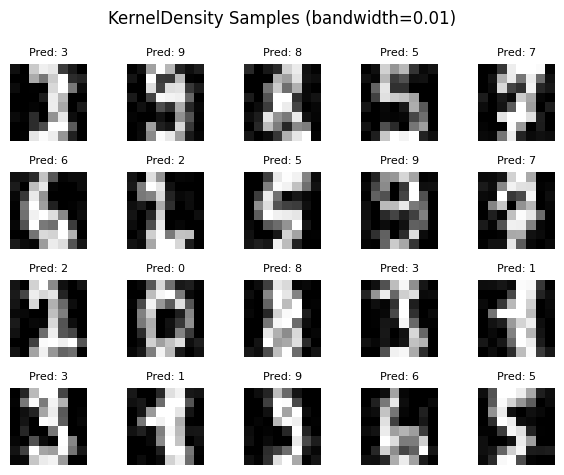

Digit 0: 89 samples
Digit 1: 92 samples
Digit 2: 117 samples
Digit 3: 87 samples
Digit 4: 92 samples
Digit 5: 111 samples
Digit 6: 98 samples
Digit 7: 105 samples
Digit 8: 112 samples
Digit 9: 97 samples


In [ ]:
n = 20

samples = kde_model_2.sample(n)
predictions = classifier.predict(samples).astype(int)

show_image_grid(
    samples, 
    n=n, 
    cols=5, 
    title="KernelDensity Samples (bandwidth=0.01)",
    predictions=predictions
)

samples = kde_model_2.sample(1000)
predictions = classifier.predict(samples).astype(int)
counts = np.bincount(predictions, minlength=10)
for digit in range(10):
    print(f"Digit {digit}: {counts[digit]} samples")

##### Bad

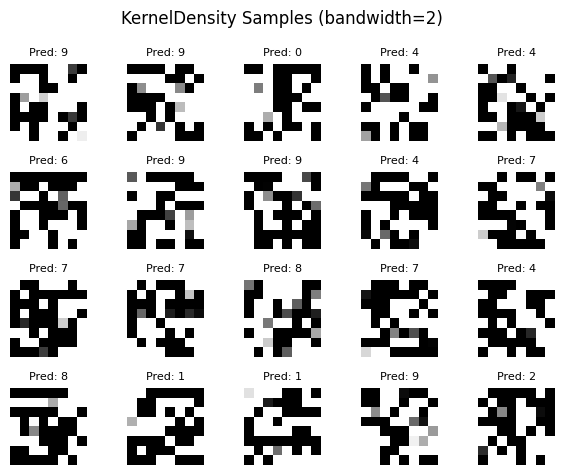

Digit 0: 90 samples
Digit 1: 107 samples
Digit 2: 81 samples
Digit 3: 38 samples
Digit 4: 205 samples
Digit 5: 167 samples
Digit 6: 64 samples
Digit 7: 104 samples
Digit 8: 62 samples
Digit 9: 82 samples


In [ ]:
n = 20

samples = kde_model_1.sample(n)
predictions = classifier.predict(samples).astype(int)

show_image_grid(
    samples, 
    n=n, 
    cols=5, 
    title="KernelDensity Samples (bandwidth=2)",
    predictions=predictions
)

samples = kde_model_1.sample(1000)
predictions = classifier.predict(samples).astype(int)
counts = np.bincount(predictions, minlength=10)
for digit in range(10):
    print(f"Digit {digit}: {counts[digit]} samples")

---
### Pro vs Con
---

##### DensityForest
Pro
- Ok fit | somewhat recognizable digits

Con
- Takes a super long to fit
- not recognizable enough for time spent
---
##### SingleGaussian
Pro
- Still Easy and fast

Con
- A lot of digits are not recognisable
- 8 very often (Data in a blob)
---
##### GMM
Pro
- Good fit
- Somewhat equal dist of digits
- Optimized, this runs very fast (even for 100 components)

Con
- Very few components -> not much better than Single
---
##### KDE
Pro
- Possibly even better fit than GMM
- Somewhat equal dist of digits

Con
- Large bandwith -> Unrecognisable and noisy